# Skin-Disorder-Prediction

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

# Dataset Understanding

In [2]:
df = pd.read_csv("skin_dermatology.csv")

df.head()

,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,...,disappearance_of_the_granular_layer,vacuolisation_and_damage_of_basal_layer,spongiosis,saw-tooth_appearance_of_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_monoluclear_inflitrate,band-like_infiltrate,Age,class
0,2,2,0,3,0,0,0,0,1,0,...,0,0,3,0,0,0,1,0,55,2
1,3,3,3,2,1,0,0,0,1,1,...,0,0,0,0,0,0,1,0,8,1
2,2,1,2,3,1,3,0,3,0,0,...,0,2,3,2,0,0,2,3,26,3
3,2,2,2,0,0,0,0,0,3,2,...,3,0,0,0,0,0,3,0,40,1
4,2,3,2,2,2,2,0,2,0,0,...,2,3,2,3,0,0,2,3,45,3


In [4]:
df.shape

(366, 35)

In [5]:
df.columns.tolist()

['erythema',
 'scaling',
 'definite_borders',
 'itching',
 'koebner_phenomenon',
 'polygonal_papules',
 'follicular_papules',
 'oral_mucosal_involvement',
 'knee_and_elbow_involvement',
 'scalp_involvement',
 'family_history',
 'melanin_incontinence',
 'eosinophils_in_the_infiltrate',
 'PNL_infiltrate',
 'fibrosis_of_the_papillary_dermis',
 'exocytosis',
 'acanthosis',
 'hyperkeratosis',
 'parakeratosis',
 'clubbing_of_the_rete_ridges',
 'elongation_of_the_rete_ridges',
 'thinning_of_the_suprapapillary_epidermis',
 'spongiform_pustule',
 'munro_microabcess',
 'focal_hypergranulosis',
 'disappearance_of_the_granular_layer',
 'vacuolisation_and_damage_of_basal_layer',
 'spongiosis',
 'saw-tooth_appearance_of_retes',
 'follicular_horn_plug',
 'perifollicular_parakeratosis',
 'inflammatory_monoluclear_inflitrate',
 'band-like_infiltrate',
 'Age',
 'class']

In [7]:
df.dtypes

erythema                                     int64
scaling                                      int64
definite_borders                             int64
itching                                      int64
koebner_phenomenon                           int64
polygonal_papules                            int64
follicular_papules                           int64
oral_mucosal_involvement                     int64
knee_and_elbow_involvement                   int64
scalp_involvement                            int64
family_history                               int64
melanin_incontinence                         int64
eosinophils_in_the_infiltrate                int64
PNL_infiltrate                               int64
fibrosis_of_the_papillary_dermis             int64
exocytosis                                   int64
acanthosis                                   int64
hyperkeratosis                               int64
parakeratosis                                int64
clubbing_of_the_rete_ridges    

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 35 columns):
 #   Column                                    Non-Null Count  Dtype 
---  ------                                    --------------  ----- 
 0   erythema                                  366 non-null    int64 
 1   scaling                                   366 non-null    int64 
 2   definite_borders                          366 non-null    int64 
 3   itching                                   366 non-null    int64 
 4   koebner_phenomenon                        366 non-null    int64 
 5   polygonal_papules                         366 non-null    int64 
 6   follicular_papules                        366 non-null    int64 
 7   oral_mucosal_involvement                  366 non-null    int64 
 8   knee_and_elbow_involvement                366 non-null    int64 
 9   scalp_involvement                         366 non-null    int64 
 10  family_history                            366 non-

In [10]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
erythema,366.0,NaN,NaN,NaN,2.068306,0.664753,0.0,2.0,2.0,2.0,3.0
scaling,366.0,NaN,NaN,NaN,1.795082,0.701527,0.0,1.0,2.0,2.0,3.0
definite_borders,366.0,NaN,NaN,NaN,1.54918,0.907525,0.0,1.0,2.0,2.0,3.0
itching,366.0,NaN,NaN,NaN,1.36612,1.138299,0.0,0.0,1.0,2.0,3.0
koebner_phenomenon,366.0,NaN,NaN,NaN,0.63388,0.908016,0.0,0.0,0.0,1.0,3.0
polygonal_papules,366.0,NaN,NaN,NaN,0.448087,0.957327,0.0,0.0,0.0,0.0,3.0
follicular_papules,366.0,NaN,NaN,NaN,0.166667,0.570588,0.0,0.0,0.0,0.0,3.0
oral_mucosal_involvement,366.0,NaN,NaN,NaN,0.377049,0.834147,0.0,0.0,0.0,0.0,3.0
knee_and_elbow_involvement,366.0,NaN,NaN,NaN,0.614754,0.982979,0.0,0.0,0.0,1.0,3.0
scalp_involvement,366.0,NaN,NaN,NaN,0.519126,0.905639,0.0,0.0,0.0,1.0,3.0


In [12]:
df.isnull().sum()

erythema                                    0
scaling                                     0
definite_borders                            0
itching                                     0
koebner_phenomenon                          0
polygonal_papules                           0
follicular_papules                          0
oral_mucosal_involvement                    0
knee_and_elbow_involvement                  0
scalp_involvement                           0
family_history                              0
melanin_incontinence                        0
eosinophils_in_the_infiltrate               0
PNL_infiltrate                              0
fibrosis_of_the_papillary_dermis            0
exocytosis                                  0
acanthosis                                  0
hyperkeratosis                              0
parakeratosis                               0
clubbing_of_the_rete_ridges                 0
elongation_of_the_rete_ridges               0
thinning_of_the_suprapapillary_epi

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
# Check unique values in each feature
for col in df.columns:
    print(f"{col}: {sorted(df[col].unique())}")

erythema: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
scaling: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
definite_borders: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
itching: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
koebner_phenomenon: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
polygonal_papules: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
follicular_papules: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
oral_mucosal_involvement: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
knee_and_elbow_involvement: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
scalp_involvement: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
family_history: [np.int64(0), np.int64(1)]
melanin_incontinence: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
eosinophils_in_the_infiltrate: [np.int64(0), np.int64(1), np.int64(2)]
PNL_infiltrate: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
fibrosis_of_the_papillary_dermis: 

In [15]:
print(df['class'].value_counts().sort_index())

class
1    112
2     61
3     72
4     49
5     52
6     20
Name: count, dtype: int64


In [16]:
print("Class percentage:")
print((df['class'].value_counts(normalize=True).sort_index() * 100).round(2))

Class percentage:
class
1    30.60
2    16.67
3    19.67
4    13.39
5    14.21
6     5.46
Name: proportion, dtype: float64


# Complete Data Quality Check

In [17]:
print("Unique Age values:")
print(df['Age'].unique())

print("\nNumber of unique Age values:", df['Age'].nunique())

Unique Age values:
['55' '8' '26' '40' '45' '41' '18' '57' '22' '30' '20' '21' '10' '65' '38'
 '23' '17' '51' '42' '44' '33' '43' '50' '34' '?' '15' '46' '62' '35' '48'
 '12' '52' '60' '32' '19' '29' '25' '36' '13' '27' '31' '28' '64' '39'
 '47' '16' '0' '7' '70' '37' '61' '67' '56' '53' '24' '58' '49' '63' '68'
 '9' '75']

Number of unique Age values: 61


In [19]:
feature_cols = df.columns.drop(['Age', 'class'])

for col in feature_cols:
    unique_values = sorted(df[col].unique())
    print(f"{col}: {unique_values}")

erythema: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
scaling: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
definite_borders: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
itching: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
koebner_phenomenon: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
polygonal_papules: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
follicular_papules: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
oral_mucosal_involvement: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
knee_and_elbow_involvement: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
scalp_involvement: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
family_history: [np.int64(0), np.int64(1)]
melanin_incontinence: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
eosinophils_in_the_infiltrate: [np.int64(0), np.int64(1), np.int64(2)]
PNL_infiltrate: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
fibrosis_of_the_papillary_dermis: 

# Data Cleaning

In [20]:
df_clean = df.copy()

print("Original Shape:", df.shape)
print("Working Dataset Shape:", df_clean.shape)

Original Shape: (366, 35)
Working Dataset Shape: (366, 35)


In [21]:
df_clean['Age'].unique()

array(['55', '8', '26', '40', '45', '41', '18', '57', '22', '30', '20',
       '21', '10', '65', '38', '23', '17', '51', '42', '44', '33', '43',
       '50', '34', '?', '15', '46', '62', '35', '48', '12', '52', '60',
       '32', '19', '29', '25', '36', '13', '27', '31', '28', '64', '39',
       '47', '16', '0', '7', '70', '37', '61', '67', '56', '53', '24',
       '58', '49', '63', '68', '9', '75'], dtype=object)

In [22]:
df_clean['Age'] = pd.to_numeric(df_clean['Age'], errors='coerce')

In [23]:
df_clean['Age'].dtype

dtype('float64')

In [24]:
df_clean['Age'].isnull().sum()

np.int64(8)

In [25]:
df_clean['Age'].describe()

count    358.000000
mean      36.296089
std       15.324557
min        0.000000
25%       25.000000
50%       35.000000
75%       49.750000
max       75.000000
Name: Age, dtype: float64

In [26]:
print("Minimum Age:", df_clean['Age'].min())
print("Maximum Age:", df_clean['Age'].max())

Minimum Age: 0.0
Maximum Age: 75.0


In [27]:
feature_cols = df_clean.columns.drop(['Age', 'class'])

invalid_values = {}

for col in feature_cols:
    invalid = df_clean.loc[
        ~df_clean[col].isin([0, 1, 2, 3]),
        col
    ].unique()
    
    if len(invalid) > 0:
        invalid_values[col] = invalid

print("Features containing invalid values:")
print(invalid_values)

Features containing invalid values:
{}


In [28]:
print("Family History values:")
print(df_clean['family_history'].unique())

Family History values:
[0 1]


In [29]:
print(sorted(df_clean['class'].unique()))

print("\nNumber of Classes:", df_clean['class'].nunique())

[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]

Number of Classes: 6


In [30]:
print("Final Shape:", df_clean.shape)

print("\nData Types:")
print(df_clean.dtypes)

print("\nMissing Values:")
print(df_clean.isnull().sum().sum())

print("\nDuplicate Rows:")
print(df_clean.duplicated().sum())

Final Shape: (366, 35)

Data Types:
erythema                                      int64
scaling                                       int64
definite_borders                              int64
itching                                       int64
koebner_phenomenon                            int64
polygonal_papules                             int64
follicular_papules                            int64
oral_mucosal_involvement                      int64
knee_and_elbow_involvement                    int64
scalp_involvement                             int64
family_history                                int64
melanin_incontinence                          int64
eosinophils_in_the_infiltrate                 int64
PNL_infiltrate                                int64
fibrosis_of_the_papillary_dermis              int64
exocytosis                                    int64
acanthosis                                    int64
hyperkeratosis                                int64
parakeratosis               

In [33]:
missing_age = df_clean[df_clean['Age'].isna()]

print("Number of missing Age records:", len(missing_age))

missing_age

Number of missing Age records: 8


,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,...,disappearance_of_the_granular_layer,vacuolisation_and_damage_of_basal_layer,spongiosis,saw-tooth_appearance_of_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_monoluclear_inflitrate,band-like_infiltrate,Age,class
33,2,2,1,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,NaN,1
34,2,1,0,0,2,0,0,0,0,0,...,0,0,0,0,0,0,0,0,NaN,4
35,2,2,1,2,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,NaN,2
36,2,1,2,3,2,3,0,2,0,0,...,0,2,0,2,0,0,0,3,NaN,3
262,2,1,0,2,0,0,0,0,0,0,...,0,0,2,0,0,0,3,0,NaN,5
263,1,1,1,3,0,0,0,0,0,0,...,0,0,3,0,0,0,2,0,NaN,5
264,1,1,0,2,0,0,0,0,1,0,...,0,0,2,0,0,0,3,0,NaN,5
265,1,1,0,3,0,0,0,0,0,0,...,0,0,2,0,0,0,3,0,NaN,5


In [34]:
print("Class distribution of missing Age records:")
print(missing_age['class'].value_counts().sort_index())

Class distribution of missing Age records:
class
1    1
2    1
3    1
4    1
5    4
Name: count, dtype: int64


In [35]:
print("Percentage of missing Age records by class:")
print(
    missing_age['class']
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

Percentage of missing Age records by class:
class
1    12.5
2    12.5
3    12.5
4    12.5
5    50.0
Name: proportion, dtype: float64


In [36]:
print(
    df_clean.groupby('class')['Age']
    .agg(['count', 'mean', 'median', 'min', 'max'])
    .round(2)
)

       count   mean  median   min   max
class                                  
1        111  39.38    39.0   0.0  75.0
2         60  35.47    34.0  10.0  70.0
3         71  39.96    40.0  16.0  65.0
4         48  35.27    35.0  12.0  70.0
5         48  36.67    35.5   8.0  70.0
6         20  10.25     9.5   7.0  22.0


In [37]:
age_zero = df_clean[df_clean['Age'] == 0]

print("Number of records with Age = 0:", len(age_zero))

age_zero[['Age', 'class']]

Number of records with Age = 0: 1


,Age,class
119,0.0,1


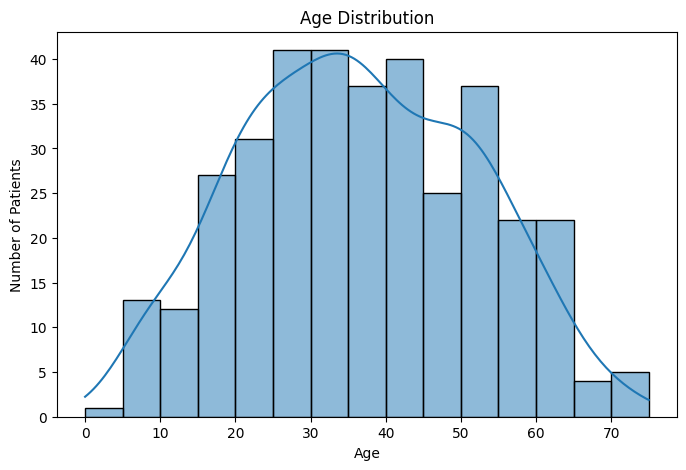

In [38]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df_clean,x='Age',bins=15,kde=True)

plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Number of Patients')

plt.show()

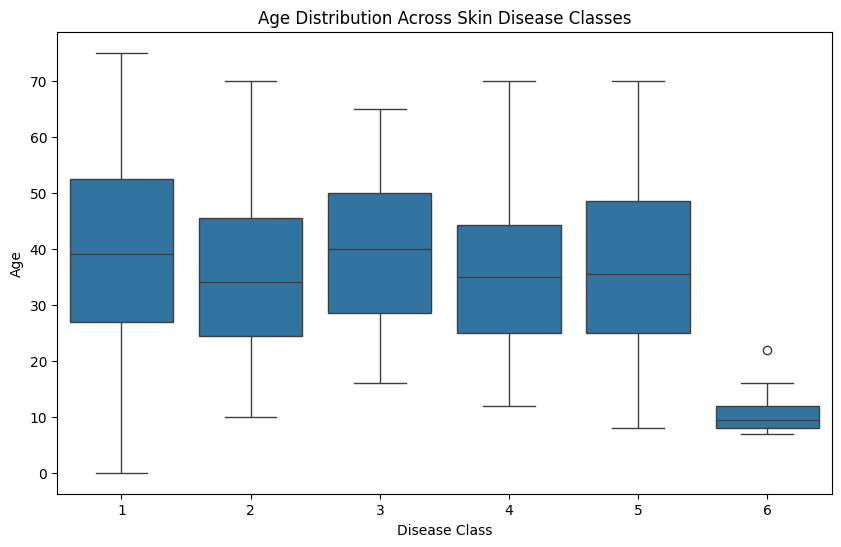

In [39]:
plt.figure(figsize=(10, 6))

sns.boxplot(data=df_clean,x='class',y='Age')

plt.title('Age Distribution Across Skin Disease Classes')
plt.xlabel('Disease Class')
plt.ylabel('Age')

plt.show()

In [41]:
# Handle Missing Age

In [40]:
age_median = df_clean['Age'].median()

print("Median Age:", age_median)

df_clean['Age'] = df_clean['Age'].fillna(age_median)

print("Missing Age values after imputation:",
      df_clean['Age'].isnull().sum())

Median Age: 35.0
Missing Age values after imputation: 0


In [42]:
print("Age values at previously missing records:")
print(df_clean.loc[missing_age.index, ['Age', 'class']])

Age values at previously missing records:
      Age  class
33   35.0      1
34   35.0      4
35   35.0      2
36   35.0      3
262  35.0      5
263  35.0      5
264  35.0      5
265  35.0      5


In [43]:
print("========== FINAL DATA QUALITY CHECK ==========")

print("\nDataset Shape:")
print(df_clean.shape)

print("\nMissing Values:")
print(df_clean.isnull().sum().sum())

print("\nDuplicate Rows:")
print(df_clean.duplicated().sum())

print("\nData Types:")
print(df_clean.dtypes)

print("\nTarget Classes:")
print(sorted(df_clean['class'].unique()))

print("\nAge Statistics:")
print(df_clean['Age'].describe())

========== FINAL DATA QUALITY CHECK ==========

Dataset Shape:
(366, 35)

Missing Values:
0

Duplicate Rows:
0

Data Types:
erythema                                      int64
scaling                                       int64
definite_borders                              int64
itching                                       int64
koebner_phenomenon                            int64
polygonal_papules                             int64
follicular_papules                            int64
oral_mucosal_involvement                      int64
knee_and_elbow_involvement                    int64
scalp_involvement                             int64
family_history                                int64
melanin_incontinence                          int64
eosinophils_in_the_infiltrate                 int64
PNL_infiltrate                                int64
fibrosis_of_the_papillary_dermis              int64
exocytosis                                    int64
acanthosis                                  

In [44]:
df_clean.to_csv("skin_dermatology_clean.csv", index=False)

print("Clean dataset saved successfully.")

Clean dataset saved successfully.


In [47]:
df_clean 

,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,...,disappearance_of_the_granular_layer,vacuolisation_and_damage_of_basal_layer,spongiosis,saw-tooth_appearance_of_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_monoluclear_inflitrate,band-like_infiltrate,Age,class
0,2,2,0,3,0,0,0,0,1,0,...,0,0,3,0,0,0,1,0,55.0,2
1,3,3,3,2,1,0,0,0,1,1,...,0,0,0,0,0,0,1,0,8.0,1
2,2,1,2,3,1,3,0,3,0,0,...,0,2,3,2,0,0,2,3,26.0,3
3,2,2,2,0,0,0,0,0,3,2,...,3,0,0,0,0,0,3,0,40.0,1
4,2,3,2,2,2,2,0,2,0,0,...,2,3,2,3,0,0,2,3,45.0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
361,2,1,1,0,1,0,0,0,0,0,...,0,0,1,0,0,0,2,0,25.0,4
362,3,2,1,0,1,0,0,0,0,0,...,1,0,1,0,0,0,2,0,36.0,4
363,3,2,2,2,3,2,0,2,0,0,...,0,3,0,3,0,0,2,3,28.0,3
364,2,1,3,1,2,3,0,2,0,0,...,0,2,0,1,0,0,2,3,50.0,3


# Exploratory Data Analysis (EDA)

### Target Variable Analysis

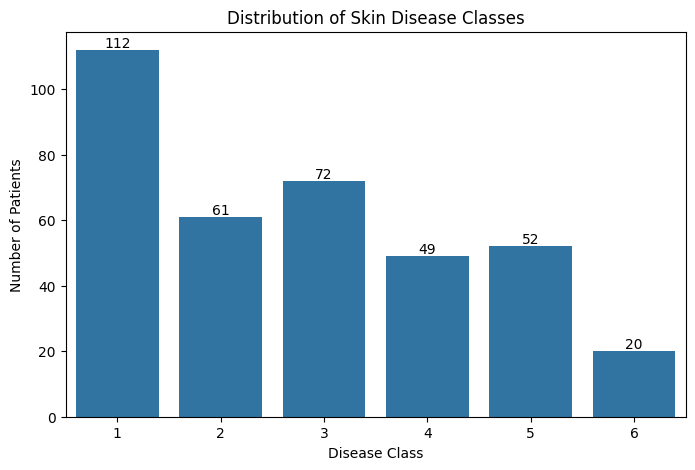

In [48]:
plt.figure(figsize=(8, 5))

ax = sns.countplot(data=df_clean,x='class')

plt.title('Distribution of Skin Disease Classes')
plt.xlabel('Disease Class')
plt.ylabel('Number of Patients')

for container in ax.containers:
    ax.bar_label(container)

plt.show()

In [49]:
class_percentage = (df_clean['class'].value_counts(normalize=True).sort_index().mul(100))

print("Class Distribution (%):")
print(class_percentage.round(2))

Class Distribution (%):
class
1    30.60
2    16.67
3    19.67
4    13.39
5    14.21
6     5.46
Name: proportion, dtype: float64


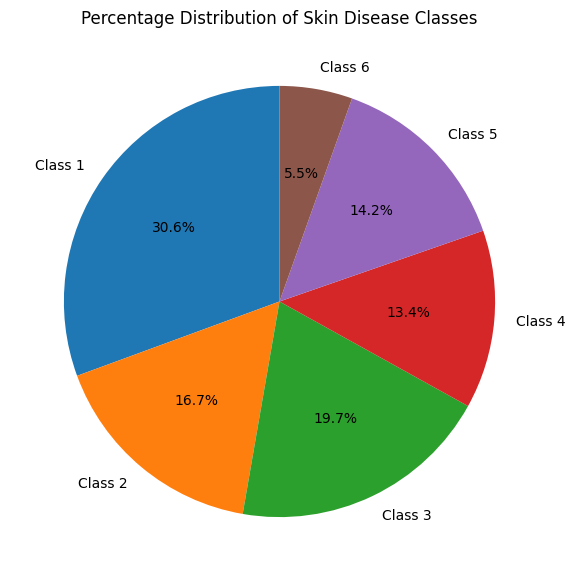

In [50]:
plt.figure(figsize=(7, 7))

class_counts = df_clean['class'].value_counts().sort_index()

plt.pie(class_counts,labels=[f'Class {i}' for i in class_counts.index],autopct='%1.1f%%',startangle=90)

plt.title('Percentage Distribution of Skin Disease Classes')
plt.show()

### Age Analysis

In [51]:
df_clean['Age'].describe()

count    366.000000
mean      36.267760
std       15.156875
min        0.000000
25%       25.000000
50%       35.000000
75%       48.000000
max       75.000000
Name: Age, dtype: float64

In [52]:
print("Mean Age:", round(df_clean['Age'].mean(), 2))
print("Median Age:", df_clean['Age'].median())
print("Minimum Age:", df_clean['Age'].min())
print("Maximum Age:", df_clean['Age'].max())

Mean Age: 36.27
Median Age: 35.0
Minimum Age: 0.0
Maximum Age: 75.0


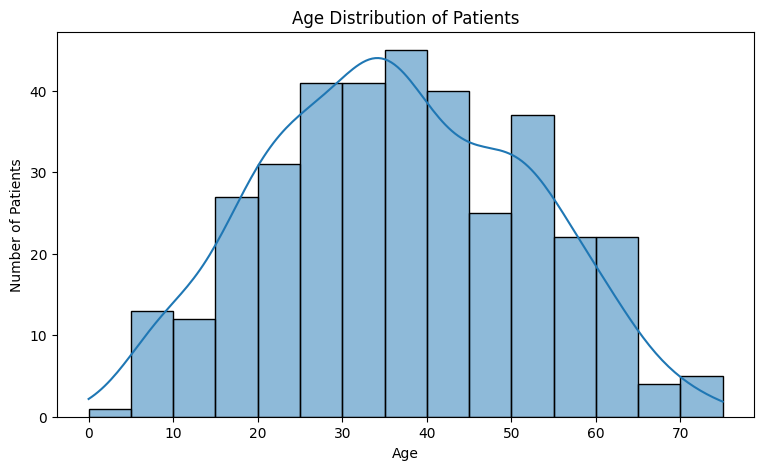

In [53]:
plt.figure(figsize=(9, 5))

sns.histplot(data=df_clean,x='Age',bins=15,kde=True)

plt.title('Age Distribution of Patients')
plt.xlabel('Age')
plt.ylabel('Number of Patients')

plt.show()

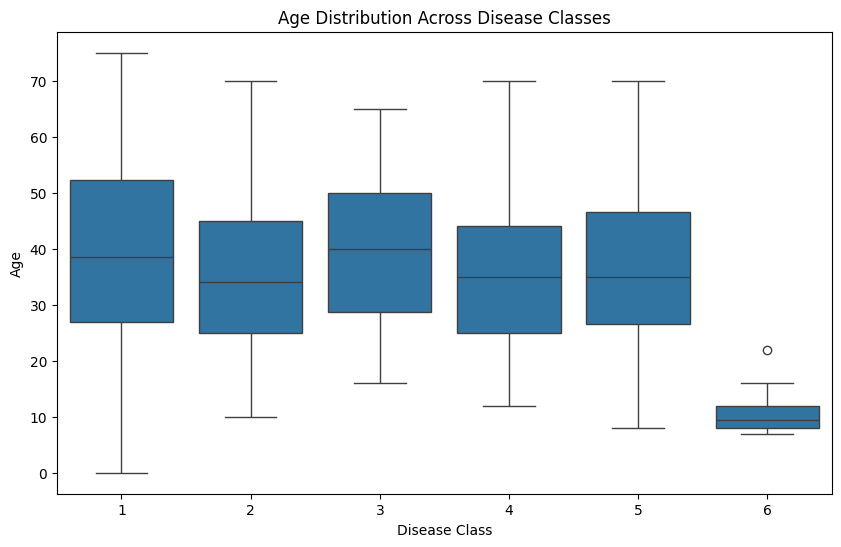

In [54]:
plt.figure(figsize=(10, 6))

sns.boxplot(data=df_clean,x='class',y='Age')

plt.title('Age Distribution Across Disease Classes')
plt.xlabel('Disease Class')
plt.ylabel('Age')

plt.show()

### Clinical Feature Analysis

In [55]:
clinical_features = [
    'erythema',
    'scaling',
    'definite_borders',
    'itching',
    'koebner_phenomenon',
    'polygonal_papules',
    'follicular_papules',
    'oral_mucosal_involvement',
    'knee_and_elbow_involvement',
    'scalp_involvement',
    'family_history'
]

In [56]:
df_clean[clinical_features].describe().T

,count,mean,std,min,25%,50%,75%,max
erythema,366.0,2.068306,0.664753,0.0,2.0,2.0,2.0,3.0
scaling,366.0,1.795082,0.701527,0.0,1.0,2.0,2.0,3.0
definite_borders,366.0,1.549180,0.907525,0.0,1.0,2.0,2.0,3.0
itching,366.0,1.366120,1.138299,0.0,0.0,1.0,2.0,3.0
koebner_phenomenon,366.0,0.633880,0.908016,0.0,0.0,0.0,1.0,3.0
polygonal_papules,366.0,0.448087,0.957327,0.0,0.0,0.0,0.0,3.0
follicular_papules,366.0,0.166667,0.570588,0.0,0.0,0.0,0.0,3.0
oral_mucosal_involvement,366.0,0.377049,0.834147,0.0,0.0,0.0,0.0,3.0
knee_and_elbow_involvement,366.0,0.614754,0.982979,0.0,0.0,0.0,1.0,3.0
scalp_involvement,366.0,0.519126,0.905639,0.0,0.0,0.0,1.0,3.0


### Average Clinical Feature Value by Class

In [57]:
clinical_by_class = df_clean.groupby('class')[clinical_features].mean()

clinical_by_class.round(2)

,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,family_history
class,,,,,,,,,,,
1,2.29,2.20,2.10,0.95,0.67,0.00,0.04,0.00,1.63,1.53,0.29
2,2.28,2.07,0.95,1.62,0.03,0.00,0.02,0.00,0.07,0.11,0.05
3,2.08,1.62,2.10,2.28,1.35,2.28,0.00,1.92,0.03,0.03,0.01
4,1.90,1.51,1.18,0.47,1.18,0.00,0.00,0.00,0.00,0.00,0.00
5,1.50,1.13,0.85,1.88,0.00,0.00,0.23,0.00,0.04,0.00,0.00
6,2.05,1.75,1.05,0.50,0.00,0.00,2.20,0.00,1.70,0.50,0.50


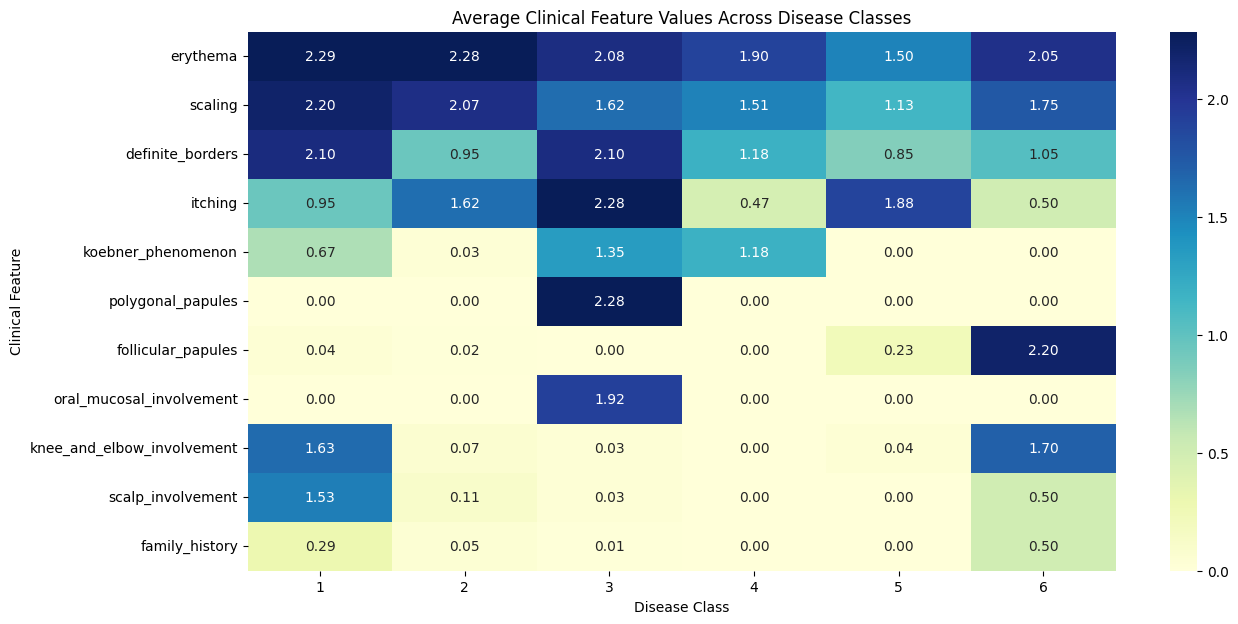

In [58]:
plt.figure(figsize=(14, 7))

sns.heatmap(clinical_by_class.T,annot=True,fmt='.2f',cmap='YlGnBu')

plt.title('Average Clinical Feature Values Across Disease Classes')
plt.xlabel('Disease Class')
plt.ylabel('Clinical Feature')

plt.show()

In [70]:
clinical_highest_class = clinical_by_class.idxmax()

clinical_highest_value = clinical_by_class.max()

clinical_summary = pd.DataFrame({
    'Highest_Class': clinical_highest_class,
    'Highest_Mean': clinical_highest_value.round(2)
})

clinical_summary

,Highest_Class,Highest_Mean
erythema,1,2.29
scaling,1,2.20
definite_borders,1,2.10
itching,3,2.28
koebner_phenomenon,3,1.35
polygonal_papules,3,2.28
follicular_papules,6,2.20
oral_mucosal_involvement,3,1.92
knee_and_elbow_involvement,6,1.70
scalp_involvement,1,1.53


### Histopathological Feature Analysis

In [59]:
histopathological_features = [
    'melanin_incontinence',
    'eosinophils_in_the_infiltrate',
    'PNL_infiltrate',
    'fibrosis_of_the_papillary_dermis',
    'exocytosis',
    'acanthosis',
    'hyperkeratosis',
    'parakeratosis',
    'clubbing_of_the_rete_ridges',
    'elongation_of_the_rete_ridges',
    'thinning_of_the_suprapapillary_epidermis',
    'spongiform_pustule',
    'munro_microabcess',
    'focal_hypergranulosis',
    'disappearance_of_the_granular_layer',
    'vacuolisation_and_damage_of_basal_layer',
    'spongiosis',
    'saw-tooth_appearance_of_retes',
    'follicular_horn_plug',
    'perifollicular_parakeratosis',
    'inflammatory_monoluclear_inflitrate',
    'band-like_infiltrate'
]

In [60]:
print("Number of histopathological features:",
      len(histopathological_features))

Number of histopathological features: 22


In [61]:
df_clean[histopathological_features].describe().T

,count,mean,std,min,25%,50%,75%,max
melanin_incontinence,366.0,0.404372,0.869818,0.0,0.0,0.0,0.0,3.0
eosinophils_in_the_infiltrate,366.0,0.139344,0.411790,0.0,0.0,0.0,0.0,2.0
PNL_infiltrate,366.0,0.546448,0.815451,0.0,0.0,0.0,1.0,3.0
fibrosis_of_the_papillary_dermis,366.0,0.336066,0.853139,0.0,0.0,0.0,0.0,3.0
exocytosis,366.0,1.368852,1.104418,0.0,0.0,2.0,2.0,3.0
acanthosis,366.0,1.956284,0.712512,0.0,2.0,2.0,2.0,3.0
hyperkeratosis,366.0,0.527322,0.757116,0.0,0.0,0.0,1.0,3.0
parakeratosis,366.0,1.289617,0.917562,0.0,1.0,1.0,2.0,3.0
clubbing_of_the_rete_ridges,366.0,0.663934,1.056829,0.0,0.0,0.0,2.0,3.0
elongation_of_the_rete_ridges,366.0,0.991803,1.162161,0.0,0.0,0.0,2.0,3.0


In [62]:
histopath_by_class = (
    df_clean.groupby('class')[histopathological_features]
    .mean()
)

histopath_by_class.round(2)

,melanin_incontinence,eosinophils_in_the_infiltrate,PNL_infiltrate,fibrosis_of_the_papillary_dermis,exocytosis,acanthosis,hyperkeratosis,parakeratosis,clubbing_of_the_rete_ridges,elongation_of_the_rete_ridges,...,munro_microabcess,focal_hypergranulosis,disappearance_of_the_granular_layer,vacuolisation_and_damage_of_basal_layer,spongiosis,saw-tooth_appearance_of_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_monoluclear_inflitrate,band-like_infiltrate
class,,,,,,,,,,,,,,,,,,,,,
1,0.00,0.04,1.12,0.00,0.27,2.10,0.82,2.00,2.12,2.26,...,1.15,0.00,1.20,0.01,0.00,0.00,0.00,0.00,1.87,0.03
2,0.00,0.46,1.08,0.00,2.20,1.77,0.21,0.98,0.00,0.16,...,0.00,0.00,0.00,0.00,2.16,0.00,0.02,0.02,1.61,0.03
3,2.06,0.17,0.00,0.06,2.26,2.11,0.29,1.21,0.00,0.00,...,0.04,1.99,0.24,2.31,1.10,2.29,0.01,0.00,2.25,2.72
4,0.00,0.06,0.12,0.00,2.04,1.45,0.31,0.76,0.00,0.00,...,0.02,0.00,0.39,0.00,1.96,0.02,0.00,0.00,1.78,0.00
5,0.00,0.08,0.00,2.29,0.85,2.25,0.69,0.75,0.08,1.88,...,0.00,0.00,0.00,0.00,0.35,0.00,0.02,0.00,1.83,0.02
6,0.00,0.00,0.15,0.00,1.50,1.65,0.80,1.25,0.10,0.10,...,0.00,0.05,0.00,0.00,1.20,0.00,1.75,2.05,1.60,0.05


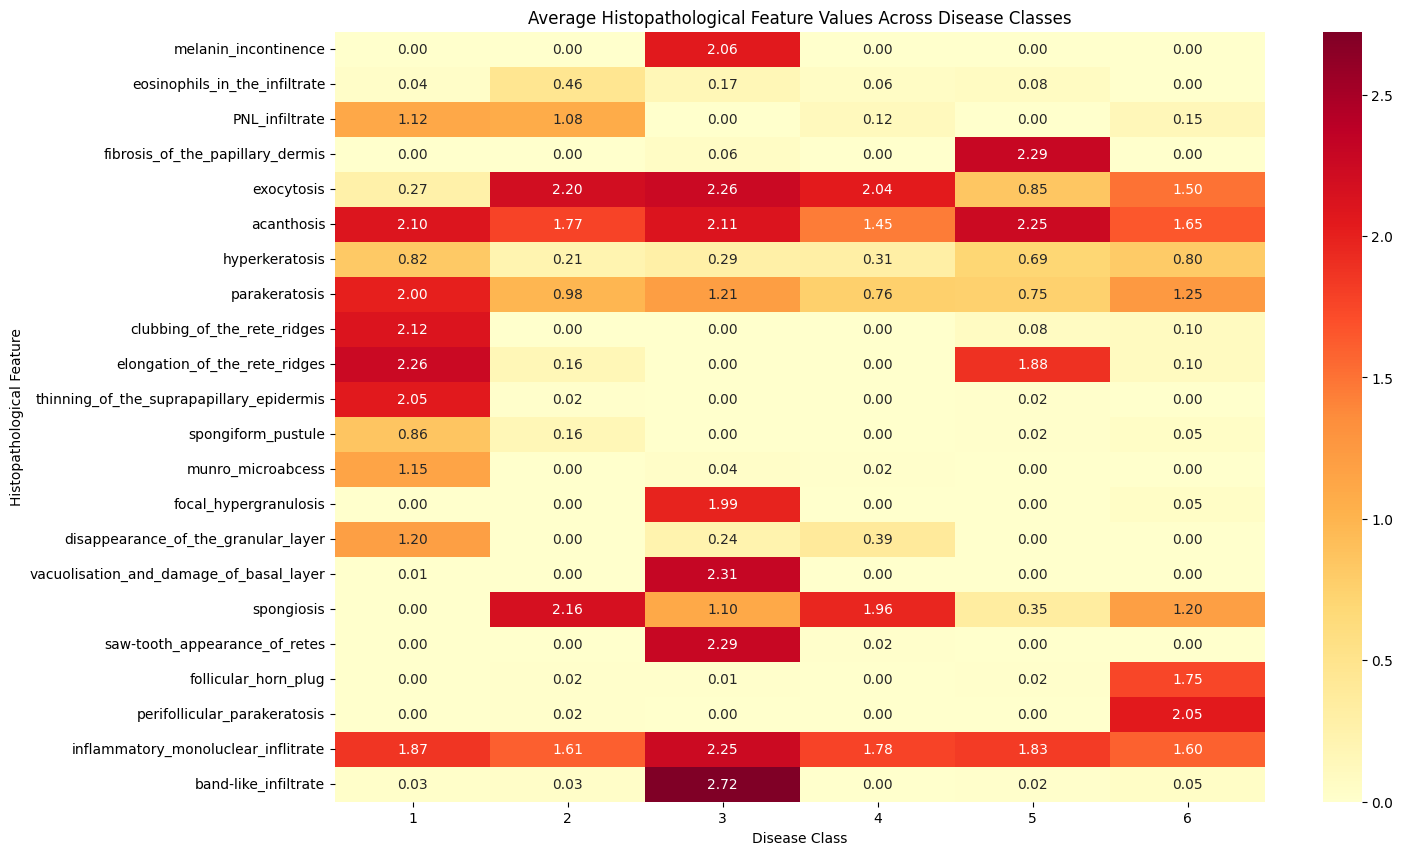

In [63]:
plt.figure(figsize=(15, 10))

sns.heatmap(histopath_by_class.T,annot=True,fmt='.2f',cmap='YlOrRd')

plt.title('Average Histopathological Feature Values Across Disease Classes')
plt.xlabel('Disease Class')
plt.ylabel('Histopathological Feature')

plt.show()

### Feature Variability

In [71]:
all_features = clinical_features + histopathological_features

class_feature_means = df_clean.groupby('class')[all_features].mean()

feature_range = (
    class_feature_means.max() - class_feature_means.min()
).sort_values(ascending=False)

feature_range_df = pd.DataFrame({
    'Feature': feature_range.index,
    'Max_Class_Mean_Difference': feature_range.values
})

feature_range_df.head(15)

,Feature,Max_Class_Mean_Difference
0,band-like_infiltrate,2.722222
1,vacuolisation_and_damage_of_basal_layer,2.305556
2,saw-tooth_appearance_of_retes,2.291667
3,fibrosis_of_the_papillary_dermis,2.288462
4,polygonal_papules,2.277778
5,elongation_of_the_rete_ridges,2.258929
6,follicular_papules,2.200000
7,spongiosis,2.163934
8,clubbing_of_the_rete_ridges,2.116071
9,melanin_incontinence,2.055556


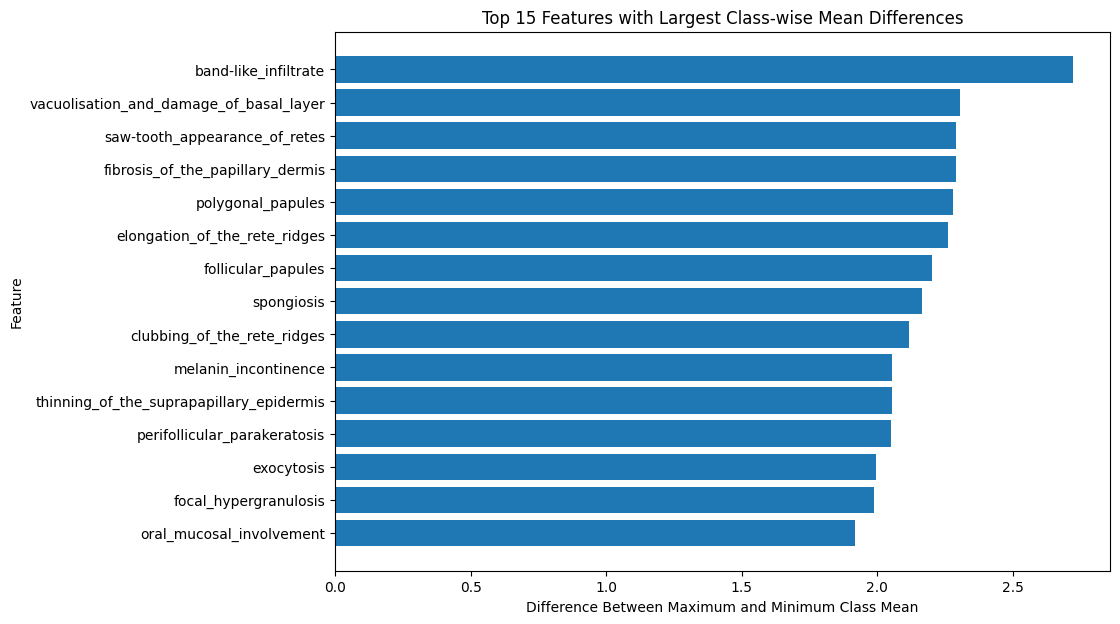

In [72]:
top_features = feature_range_df.head(15).sort_values(
    'Max_Class_Mean_Difference'
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features['Feature'],
    top_features['Max_Class_Mean_Difference']
)

plt.title('Top 15 Features with Largest Class-wise Mean Differences')
plt.xlabel('Difference Between Maximum and Minimum Class Mean')
plt.ylabel('Feature')

plt.show()

### Correlation Analysis

In [73]:
feature_columns = clinical_features + histopathological_features + ['Age']

correlation_matrix = df_clean[feature_columns].corr()

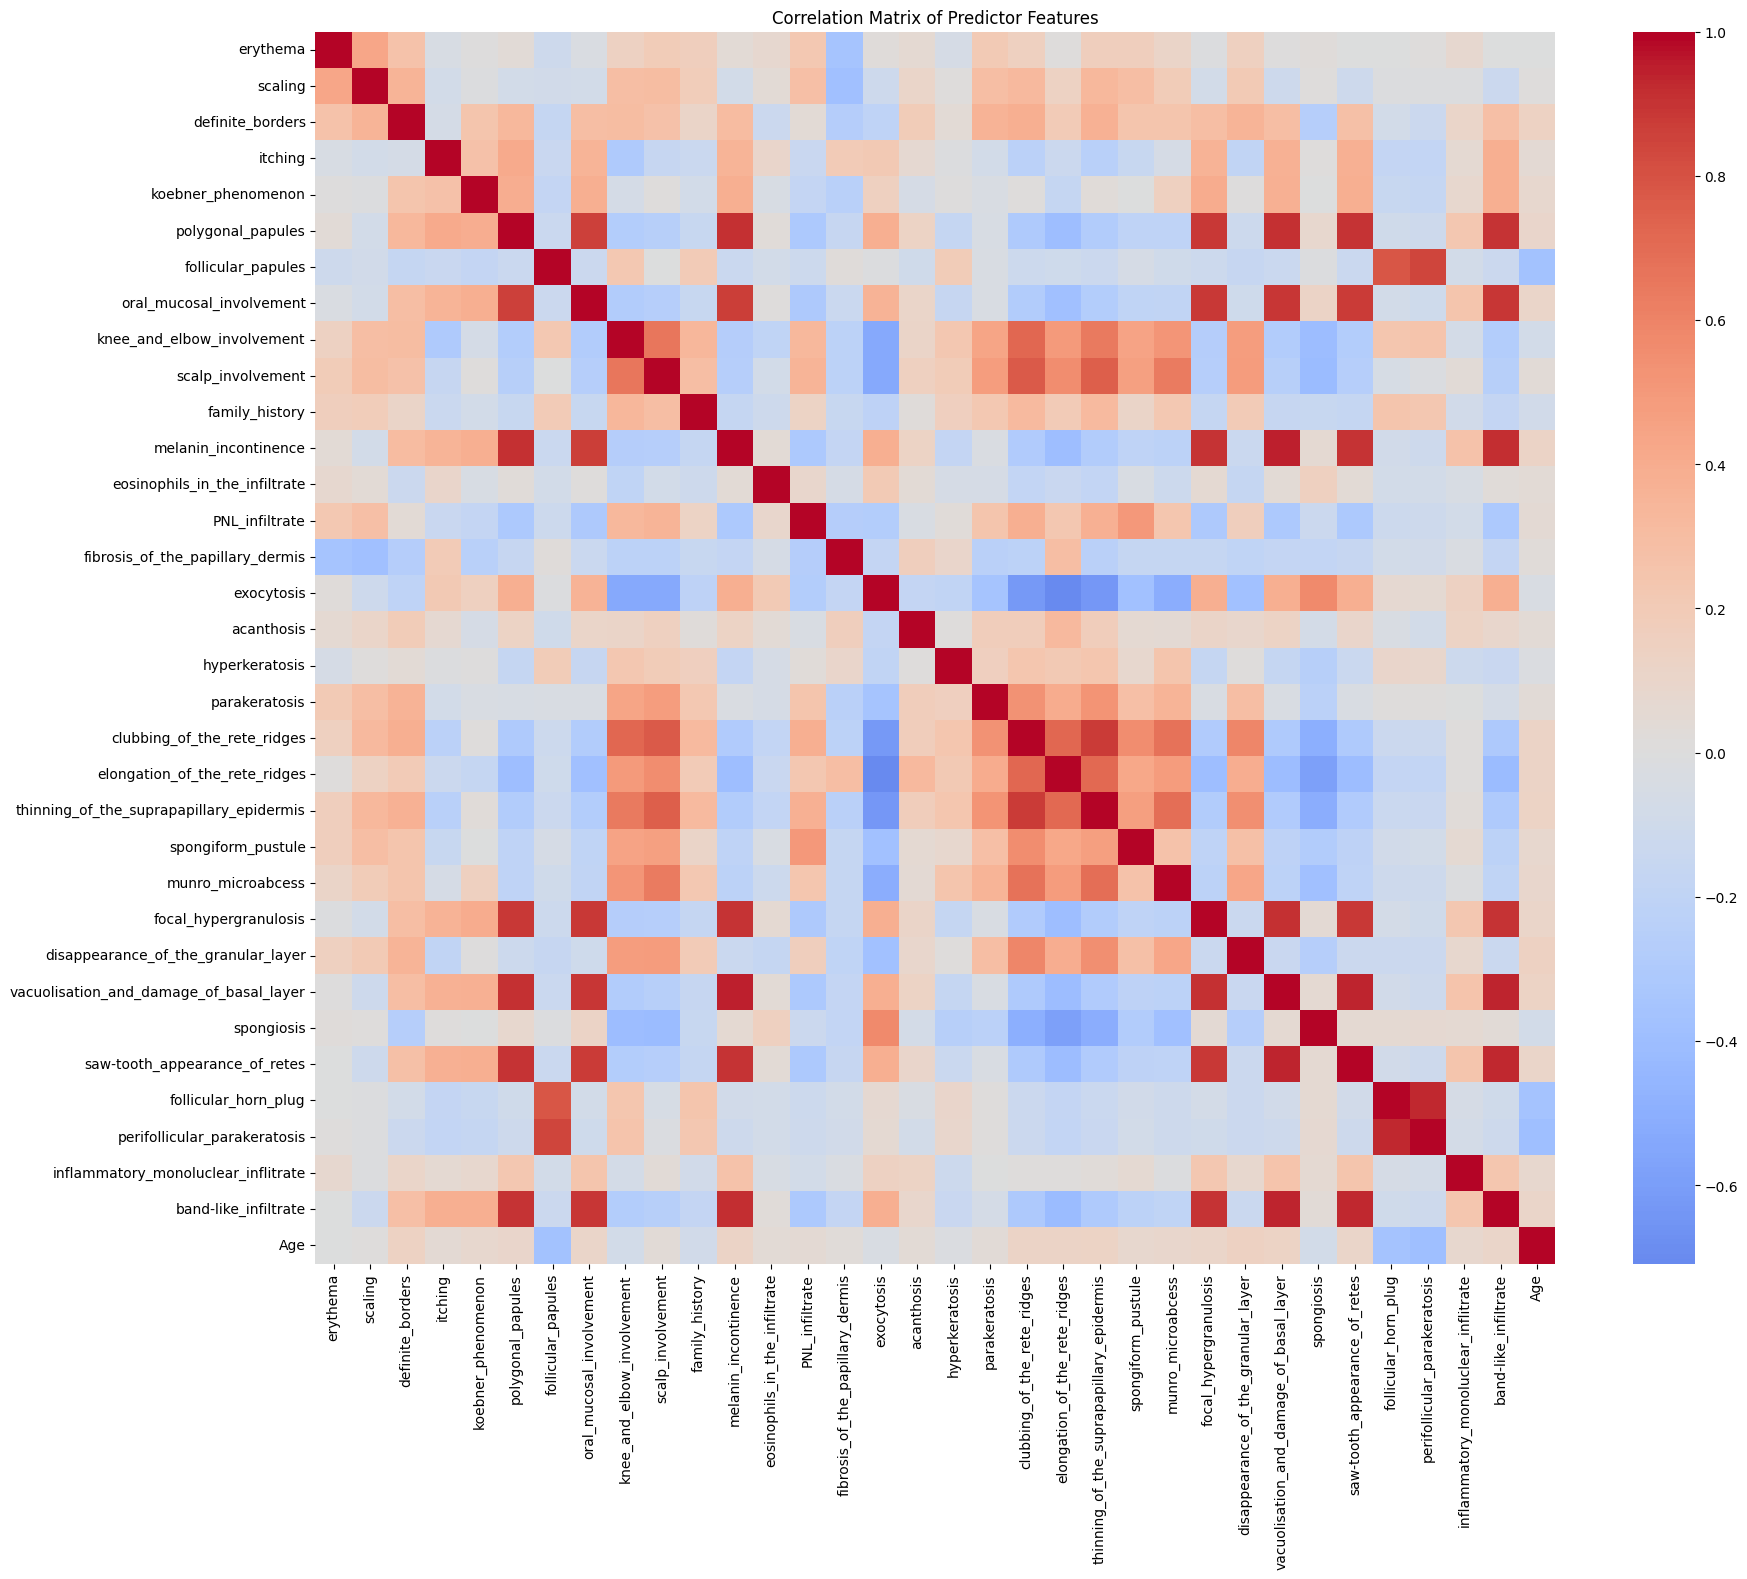

In [74]:
plt.figure(figsize=(20, 16))

sns.heatmap(correlation_matrix,cmap='coolwarm',center=0)

plt.title('Correlation Matrix of Predictor Features')
plt.show()

### Find Strong Feature Correlations

In [75]:
feature_corr = df_clean[feature_columns].corr()

upper_triangle = feature_corr.where(np.triu(np.ones(feature_corr.shape), k=1).astype(bool))

strong_correlations = (upper_triangle.stack().sort_values(key=abs, ascending=False))

print("Top 20 Feature Correlations:")
print(strong_correlations.head(20))

Top 20 Feature Correlations:
melanin_incontinence                     vacuolisation_and_damage_of_basal_layer     0.941659
vacuolisation_and_damage_of_basal_layer  saw-tooth_appearance_of_retes               0.938397
                                         band-like_infiltrate                        0.937561
follicular_horn_plug                     perifollicular_parakeratosis                0.928929
saw-tooth_appearance_of_retes            band-like_infiltrate                        0.928748
melanin_incontinence                     band-like_infiltrate                        0.916848
polygonal_papules                        vacuolisation_and_damage_of_basal_layer     0.911626
focal_hypergranulosis                    vacuolisation_and_damage_of_basal_layer     0.909650
polygonal_papules                        melanin_incontinence                        0.907044
                                         band-like_infiltrate                        0.905822
focal_hypergranulosis          

### Check for Highly Correlated Features

In [77]:
high_corr = (
    upper_triangle
    .stack()
    .reset_index()
)

high_corr.columns = ['Feature_1', 'Feature_2', 'Correlation']

high_corr = high_corr[
    high_corr['Correlation'].abs() >= 0.70
].sort_values(
    'Correlation',
    key=abs,
    ascending=False
)

high_corr

,Feature_1,Feature_2,Correlation
322,melanin_incontinence,vacuolisation_and_damage_of_basal_layer,0.941659
534,vacuolisation_and_damage_of_basal_layer,saw-tooth_appearance_of_retes,0.938397
538,vacuolisation_and_damage_of_basal_layer,band-like_infiltrate,0.937561
551,follicular_horn_plug,perifollicular_parakeratosis,0.928929
549,saw-tooth_appearance_of_retes,band-like_infiltrate,0.928748
328,melanin_incontinence,band-like_infiltrate,0.916848
175,polygonal_papules,vacuolisation_and_damage_of_basal_layer,0.911626
517,focal_hypergranulosis,vacuolisation_and_damage_of_basal_layer,0.909650
160,polygonal_papules,melanin_incontinence,0.907044
181,polygonal_papules,band-like_infiltrate,0.905822


### Feature Distribution by Class

In [78]:
top_6_features = feature_range_df.head(6)['Feature'].tolist()

print("Top 6 class-differentiating features:")
print(top_6_features)

Top 6 class-differentiating features:
['band-like_infiltrate', 'vacuolisation_and_damage_of_basal_layer', 'saw-tooth_appearance_of_retes', 'fibrosis_of_the_papillary_dermis', 'polygonal_papules', 'elongation_of_the_rete_ridges']


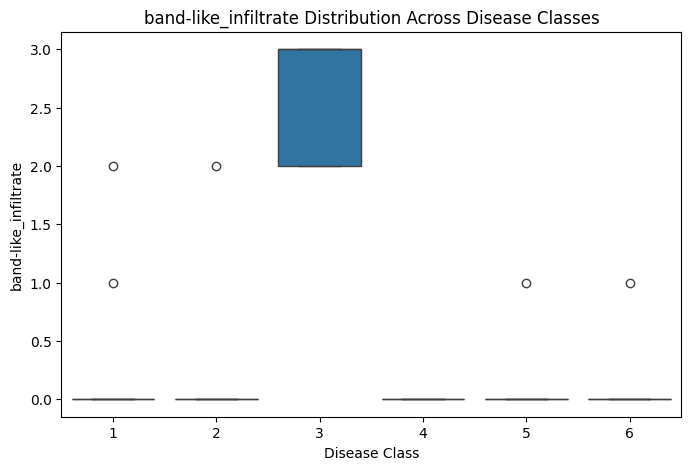

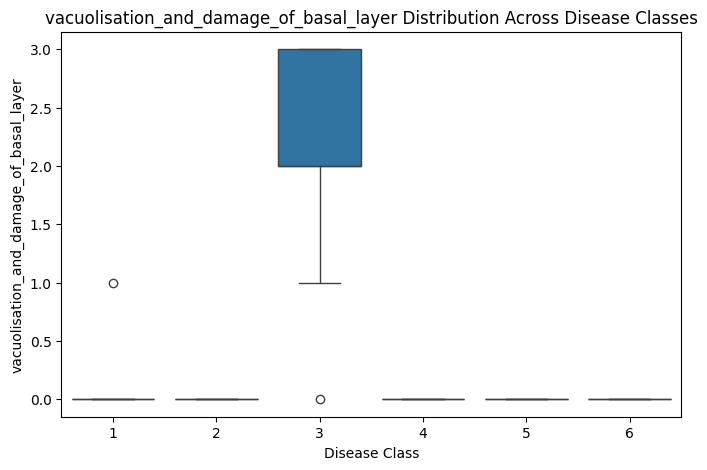

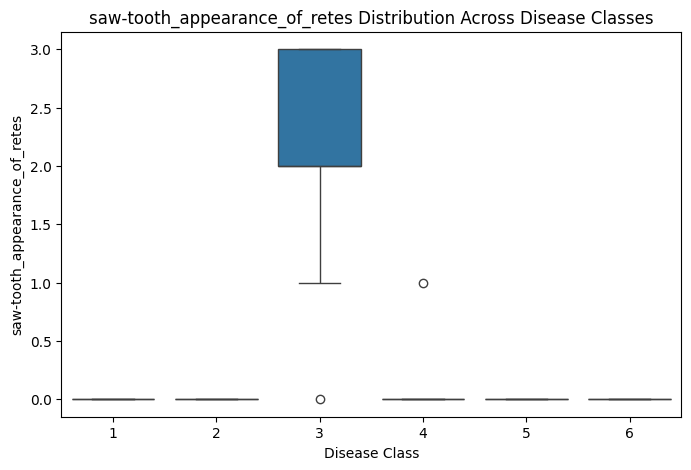

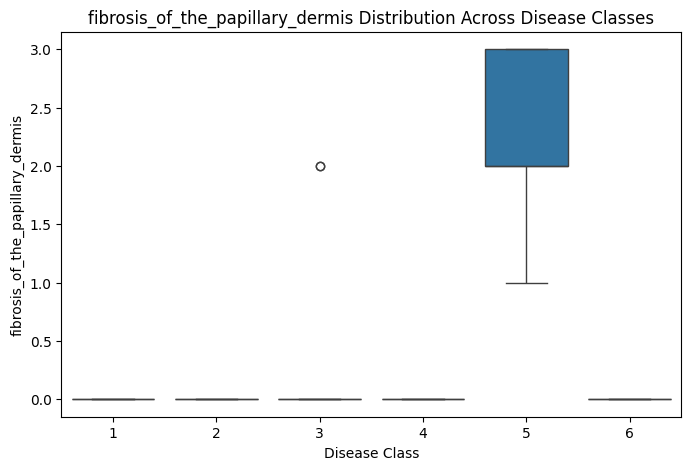

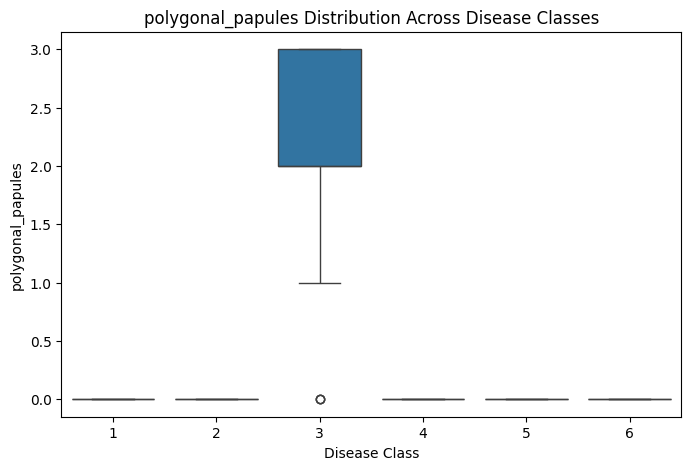

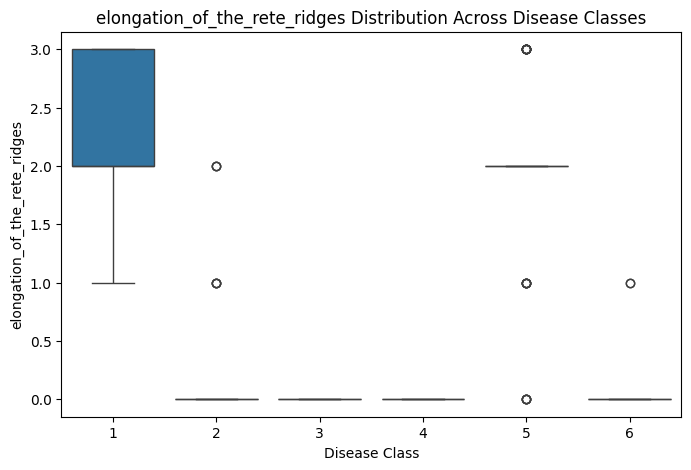

In [79]:
for feature in top_6_features:
    plt.figure(figsize=(8, 5))
    
    sns.boxplot(data=df_clean,x='class',y=feature)
    
    plt.title(f'{feature} Distribution Across Disease Classes')
    plt.xlabel('Disease Class')
    plt.ylabel(feature)
    
    plt.show()

# Data Preprocessing

In [80]:
X = df_clean.drop('class', axis=1)
y = df_clean['class']

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (366, 34)
y Shape: (366,)


In [81]:
print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

Features:
['erythema', 'scaling', 'definite_borders', 'itching', 'koebner_phenomenon', 'polygonal_papules', 'follicular_papules', 'oral_mucosal_involvement', 'knee_and_elbow_involvement', 'scalp_involvement', 'family_history', 'melanin_incontinence', 'eosinophils_in_the_infiltrate', 'PNL_infiltrate', 'fibrosis_of_the_papillary_dermis', 'exocytosis', 'acanthosis', 'hyperkeratosis', 'parakeratosis', 'clubbing_of_the_rete_ridges', 'elongation_of_the_rete_ridges', 'thinning_of_the_suprapapillary_epidermis', 'spongiform_pustule', 'munro_microabcess', 'focal_hypergranulosis', 'disappearance_of_the_granular_layer', 'vacuolisation_and_damage_of_basal_layer', 'spongiosis', 'saw-tooth_appearance_of_retes', 'follicular_horn_plug', 'perifollicular_parakeratosis', 'inflammatory_monoluclear_inflitrate', 'band-like_infiltrate', 'Age']

Target:
class


## Train-Test Split

In [82]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (292, 34)
X_test : (74, 34)
y_train: (292,)
y_test : (74,)


In [83]:
print("Original class distribution:")
print(y.value_counts(normalize=True).sort_index().round(3))

print("\nTraining class distribution:")
print(y_train.value_counts(normalize=True).sort_index().round(3))

print("\nTesting class distribution:")
print(y_test.value_counts(normalize=True).sort_index().round(3))

Original class distribution:
class
1    0.306
2    0.167
3    0.197
4    0.134
5    0.142
6    0.055
Name: proportion, dtype: float64

Training class distribution:
class
1    0.305
2    0.168
3    0.195
4    0.134
5    0.144
6    0.055
Name: proportion, dtype: float64

Testing class distribution:
class
1    0.311
2    0.162
3    0.203
4    0.135
5    0.135
6    0.054
Name: proportion, dtype: float64


In [84]:
print("Training Set:")
print(y_train.value_counts().sort_index())

print("\nTest Set:")
print(y_test.value_counts().sort_index())

Training Set:
class
1    89
2    49
3    57
4    39
5    42
6    16
Name: count, dtype: int64

Test Set:
class
1    23
2    12
3    15
4    10
5    10
6     4
Name: count, dtype: int64


### Baseline Model Setup

In [85]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [86]:
def evaluate_model(model, X_train, X_test, y_train, y_test):
    
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    
    print("Accuracy :", round(accuracy, 4))
    print("Precision:", round(precision, 4))
    print("Recall   :", round(recall, 4))
    print("F1 Score :", round(f1, 4))
    
    return model, y_pred

# Logistic Regression Model

In [87]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

logistic_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        max_iter=2000,
        random_state=42
    ))
])

In [88]:
logistic_model, logistic_pred = evaluate_model(logistic_pipeline,X_train,X_test,y_train,y_test)

Accuracy : 0.9595
Precision: 0.9688
Recall   : 0.9595
F1 Score : 0.9606


In [89]:
print(classification_report(y_test,logistic_pred,zero_division=0))

              precision    recall  f1-score   support

           1       1.00      1.00      1.00        23
           2       1.00      0.83      0.91        12
           3       1.00      0.93      0.97        15
           4       0.77      1.00      0.87        10
           5       1.00      1.00      1.00        10
           6       1.00      1.00      1.00         4

    accuracy                           0.96        74
   macro avg       0.96      0.96      0.96        74
weighted avg       0.97      0.96      0.96        74



In [90]:
cm_logistic = confusion_matrix(y_test, logistic_pred)

print(cm_logistic)

[[23  0  0  0  0  0]
 [ 0 10  0  2  0  0]
 [ 0  0 14  1  0  0]
 [ 0  0  0 10  0  0]
 [ 0  0  0  0 10  0]
 [ 0  0  0  0  0  4]]


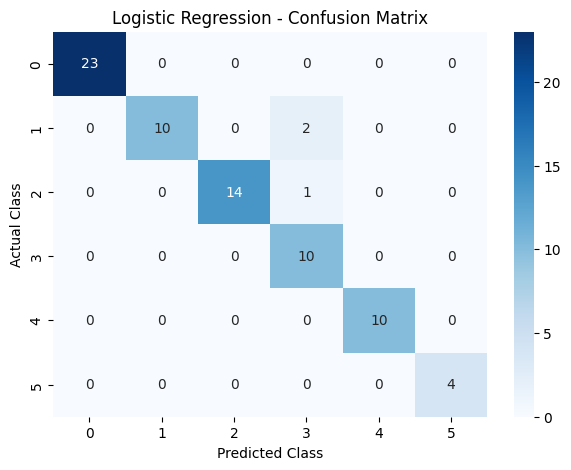

In [91]:
plt.figure(figsize=(7, 5))

sns.heatmap(cm_logistic,annot=True,fmt='d',cmap='Blues')

plt.title('Logistic Regression - Confusion Matrix')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')

plt.show()

In [92]:
macro_f1 = f1_score(y_test,logistic_pred,average='macro')

weighted_f1 = f1_score(y_test,logistic_pred,average='weighted')

print("Macro F1   :", round(macro_f1, 4))
print("Weighted F1:", round(weighted_f1, 4))

Macro F1   : 0.9574
Weighted F1: 0.9606


In [93]:
results = []

results.append({
    'Model': 'Logistic Regression',
    'Accuracy': accuracy_score(y_test, logistic_pred),
    'Precision_Weighted': precision_score(
        y_test, logistic_pred,
        average='weighted',
        zero_division=0
    ),
    'Recall_Weighted': recall_score(
        y_test, logistic_pred,
        average='weighted',
        zero_division=0
    ),
    'F1_Weighted': f1_score(
        y_test, logistic_pred,
        average='weighted',
        zero_division=0
    ),
    'F1_Macro': f1_score(
        y_test, logistic_pred,
        average='macro',
        zero_division=0
    )
})

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision_Weighted,Recall_Weighted,F1_Weighted,F1_Macro
0,Logistic Regression,0.959459,0.968815,0.959459,0.960642,0.957362


# KNN Model

In [94]:
from sklearn.neighbors import KNeighborsClassifier

knn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', KNeighborsClassifier(
        n_neighbors=5
    ))
])

In [95]:
knn_model, knn_pred = evaluate_model(knn_pipeline,X_train,X_test,y_train,y_test)

Accuracy : 0.9054
Precision: 0.9193
Recall   : 0.9054
F1 Score : 0.9081


In [96]:
print(classification_report(y_test,knn_pred,zero_division=0))

              precision    recall  f1-score   support

           1       1.00      0.96      0.98        23
           2       0.80      0.67      0.73        12
           3       1.00      0.93      0.97        15
           4       0.64      0.90      0.75        10
           5       1.00      1.00      1.00        10
           6       1.00      1.00      1.00         4

    accuracy                           0.91        74
   macro avg       0.91      0.91      0.90        74
weighted avg       0.92      0.91      0.91        74



In [97]:
knn_macro_f1 = f1_score(y_test,knn_pred,average='macro',zero_division=0)

knn_weighted_f1 = f1_score(y_test,knn_pred,average='weighted',zero_division=0)

print("Macro F1   :", round(knn_macro_f1, 4))
print("Weighted F1:", round(knn_weighted_f1, 4))

Macro F1   : 0.9034
Weighted F1: 0.9081


[[22  1  0  0  0  0]
 [ 0  8  0  4  0  0]
 [ 0  0 14  1  0  0]
 [ 0  1  0  9  0  0]
 [ 0  0  0  0 10  0]
 [ 0  0  0  0  0  4]]


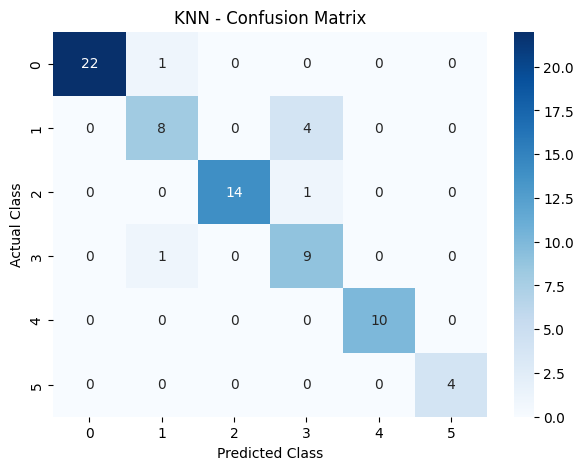

In [98]:
cm_knn = confusion_matrix(y_test, knn_pred)

print(cm_knn)

plt.figure(figsize=(7, 5))

sns.heatmap(cm_knn,annot=True,fmt='d',cmap='Blues')

plt.title('KNN - Confusion Matrix')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')

plt.show()

# Decision Tree Model

In [99]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)

In [100]:
dt_model, dt_pred = evaluate_model(dt_model,X_train,X_test,y_train,y_test)

Accuracy : 0.9324
Precision: 0.9382
Recall   : 0.9324
F1 Score : 0.9292


In [101]:
print(classification_report(y_test,dt_pred,zero_division=0))

              precision    recall  f1-score   support

           1       1.00      1.00      1.00        23
           2       0.83      0.83      0.83        12
           3       1.00      0.93      0.97        15
           4       0.83      1.00      0.91        10
           5       0.91      1.00      0.95        10
           6       1.00      0.50      0.67         4

    accuracy                           0.93        74
   macro avg       0.93      0.88      0.89        74
weighted avg       0.94      0.93      0.93        74



In [102]:
dt_macro_f1 = f1_score(y_test,dt_pred,average='macro',zero_division=0)

dt_weighted_f1 = f1_score(y_test,dt_pred,average='weighted',zero_division=0)

print("Macro F1   :", round(dt_macro_f1, 4))
print("Weighted F1:", round(dt_weighted_f1, 4))

Macro F1   : 0.8878
Weighted F1: 0.9292


[[23  0  0  0  0  0]
 [ 0 10  0  2  0  0]
 [ 0  0 14  0  1  0]
 [ 0  0  0 10  0  0]
 [ 0  0  0  0 10  0]
 [ 0  2  0  0  0  2]]


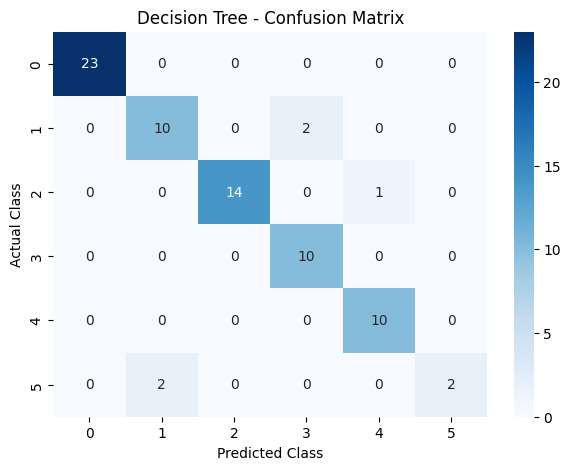

In [103]:
cm_dt = confusion_matrix(y_test, dt_pred)

print(cm_dt)

plt.figure(figsize=(7, 5))

sns.heatmap(cm_dt,annot=True,fmt='d',cmap='Blues')

plt.title('Decision Tree - Confusion Matrix')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')

plt.show()

In [104]:
dt_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': dt_model.feature_importances_
}).sort_values(
    'Importance',
    ascending=False
)

dt_importance.head(15)

,Feature,Importance
19,clubbing_of_the_rete_ridges,0.306649
26,vacuolisation_and_damage_of_basal_layer,0.223901
14,fibrosis_of_the_papillary_dermis,0.174434
4,koebner_phenomenon,0.125500
30,perifollicular_parakeratosis,0.084484
25,disappearance_of_the_granular_layer,0.027809
29,follicular_horn_plug,0.016575
17,hyperkeratosis,0.008654
27,spongiosis,0.008473
21,thinning_of_the_suprapapillary_epidermis,0.007950


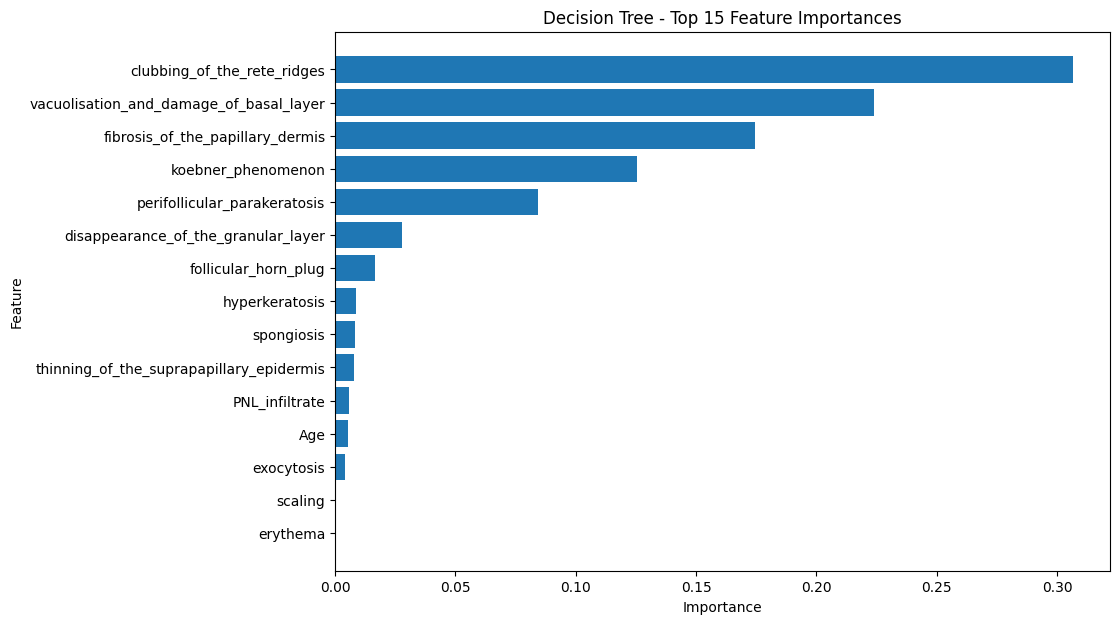

In [105]:
top_dt_features = dt_importance.head(15).sort_values('Importance')

plt.figure(figsize=(10, 7))

plt.barh(
    top_dt_features['Feature'],
    top_dt_features['Importance']
)

plt.title('Decision Tree - Top 15 Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')

plt.show()

# Random Forest Model

In [106]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=200,random_state=42)

In [107]:
rf_model, rf_pred = evaluate_model(rf_model,X_train,X_test,y_train,y_test)

Accuracy : 0.9595
Precision: 0.9607
Recall   : 0.9595
F1 Score : 0.9595


In [108]:
print(classification_report(y_test,rf_pred,zero_division=0))

              precision    recall  f1-score   support

           1       1.00      1.00      1.00        23
           2       0.91      0.83      0.87        12
           3       1.00      1.00      1.00        15
           4       0.82      0.90      0.86        10
           5       1.00      1.00      1.00        10
           6       1.00      1.00      1.00         4

    accuracy                           0.96        74
   macro avg       0.95      0.96      0.95        74
weighted avg       0.96      0.96      0.96        74



In [109]:
rf_macro_f1 = f1_score(y_test,rf_pred,average='macro',zero_division=0)

rf_weighted_f1 = f1_score(y_test,rf_pred,average='weighted',zero_division=0)

print("Macro F1   :", round(rf_macro_f1, 4))
print("Weighted F1:", round(rf_weighted_f1, 4))

Macro F1   : 0.9545
Weighted F1: 0.9595


[[23  0  0  0  0  0]
 [ 0 10  0  2  0  0]
 [ 0  0 15  0  0  0]
 [ 0  1  0  9  0  0]
 [ 0  0  0  0 10  0]
 [ 0  0  0  0  0  4]]


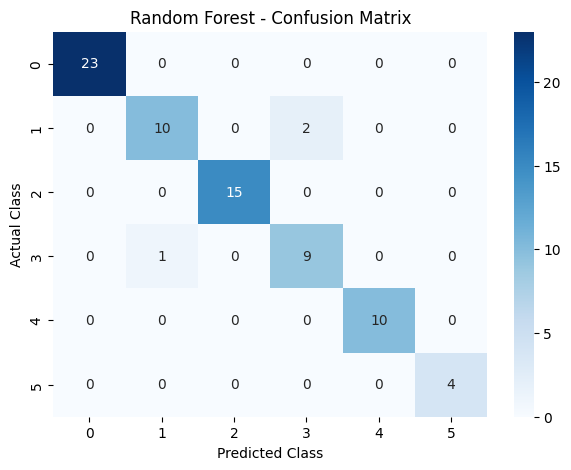

In [110]:
cm_rf = confusion_matrix(y_test, rf_pred)

print(cm_rf)

plt.figure(figsize=(7, 5))

sns.heatmap(cm_rf,annot=True,fmt='d',cmap='Blues')

plt.title('Random Forest - Confusion Matrix')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')

plt.show()

In [111]:
rf_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(
    'Importance',
    ascending=False
)

rf_importance.head(15)

,Feature,Importance
19,clubbing_of_the_rete_ridges,0.103995
14,fibrosis_of_the_papillary_dermis,0.078025
21,thinning_of_the_suprapapillary_epidermis,0.070083
4,koebner_phenomenon,0.061630
27,spongiosis,0.055657
20,elongation_of_the_rete_ridges,0.054517
13,PNL_infiltrate,0.041216
26,vacuolisation_and_damage_of_basal_layer,0.039338
28,saw-tooth_appearance_of_retes,0.038373
32,band-like_infiltrate,0.034791


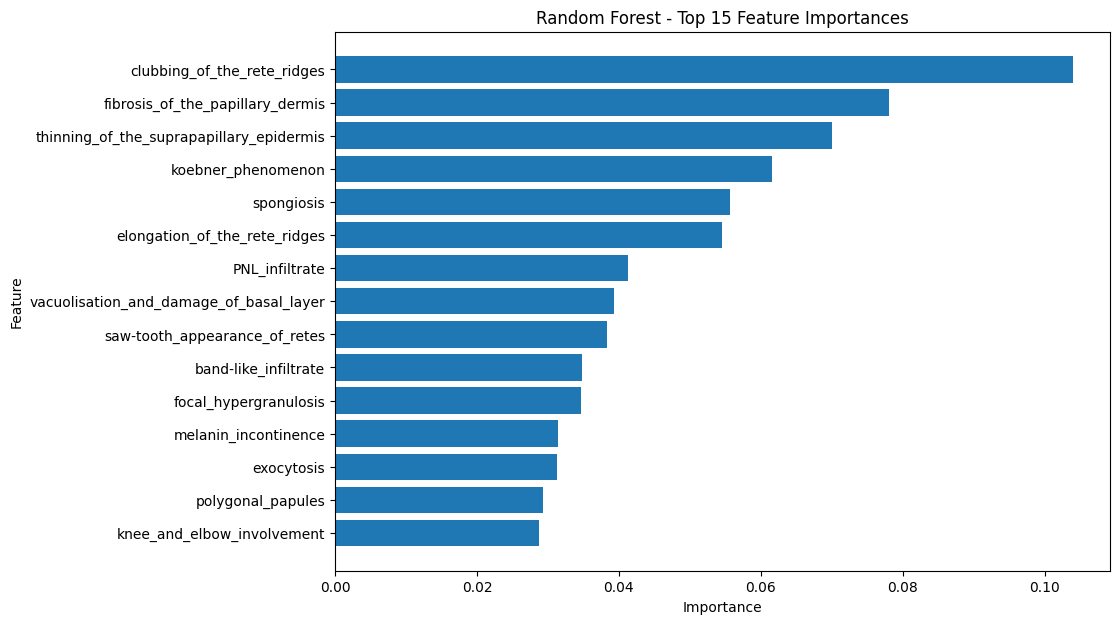

In [112]:
top_rf_features = rf_importance.head(15).sort_values('Importance')

plt.figure(figsize=(10, 7))

plt.barh(
    top_rf_features['Feature'],
    top_rf_features['Importance']
)

plt.title('Random Forest - Top 15 Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')

plt.show()

In [113]:
results = []

model_predictions = {
    'Logistic Regression': logistic_pred,
    'KNN': knn_pred,
    'Decision Tree': dt_pred,
    'Random Forest': rf_pred
}

for model_name, predictions in model_predictions.items():
    
    results.append({
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, predictions),
        'Precision_Weighted': precision_score(
            y_test, predictions,
            average='weighted',
            zero_division=0
        ),
        'Recall_Weighted': recall_score(
            y_test, predictions,
            average='weighted',
            zero_division=0
        ),
        'F1_Weighted': f1_score(
            y_test, predictions,
            average='weighted',
            zero_division=0
        ),
        'F1_Macro': f1_score(
            y_test, predictions,
            average='macro',
            zero_division=0
        )
    })

results_df = pd.DataFrame(results)

results_df.sort_values('F1_Macro',ascending=False).reset_index(drop=True)

,Model,Accuracy,Precision_Weighted,Recall_Weighted,F1_Weighted,F1_Macro
0,Logistic Regression,0.959459,0.968815,0.959459,0.960642,0.957362
1,Random Forest,0.959459,0.960688,0.959459,0.959543,0.954451
2,KNN,0.905405,0.919305,0.905405,0.908094,0.903428
3,Decision Tree,0.932432,0.938165,0.932432,0.929245,0.887832


# SVM Model

In [114]:
from sklearn.svm import SVC

svm_pipeline = Pipeline([('scaler', StandardScaler()),('model', SVC(kernel='rbf',random_state=42))])

In [115]:
svm_model, svm_pred = evaluate_model(svm_pipeline,X_train,X_test,y_train,y_test)

Accuracy : 0.973
Precision: 0.9775
Recall   : 0.973
F1 Score : 0.973


In [116]:
print(classification_report(y_test,svm_pred,zero_division=0))

              precision    recall  f1-score   support

           1       1.00      1.00      1.00        23
           2       1.00      0.83      0.91        12
           3       1.00      1.00      1.00        15
           4       0.83      1.00      0.91        10
           5       1.00      1.00      1.00        10
           6       1.00      1.00      1.00         4

    accuracy                           0.97        74
   macro avg       0.97      0.97      0.97        74
weighted avg       0.98      0.97      0.97        74



In [117]:
svm_macro_f1 = f1_score(y_test,svm_pred,average='macro',zero_division=0)

svm_weighted_f1 = f1_score(y_test,svm_pred,average='weighted',zero_division=0)

print("Macro F1   :", round(svm_macro_f1, 4))
print("Weighted F1:", round(svm_weighted_f1, 4))

Macro F1   : 0.9697
Weighted F1: 0.973


[[23  0  0  0  0  0]
 [ 0 10  0  2  0  0]
 [ 0  0 15  0  0  0]
 [ 0  0  0 10  0  0]
 [ 0  0  0  0 10  0]
 [ 0  0  0  0  0  4]]


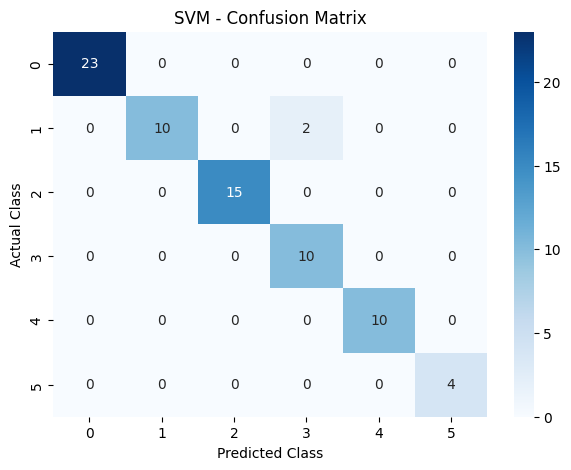

In [118]:
cm_svm = confusion_matrix(y_test, svm_pred)

print(cm_svm)

plt.figure(figsize=(7, 5))

sns.heatmap(cm_svm,annot=True,fmt='d',cmap='Blues')

plt.title('SVM - Confusion Matrix')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')

plt.show()

In [119]:
results.append({
    'Model': 'SVM',
    'Accuracy': accuracy_score(y_test, svm_pred),
    'Precision_Weighted': precision_score(
        y_test,
        svm_pred,
        average='weighted',
        zero_division=0
    ),
    'Recall_Weighted': recall_score(
        y_test,
        svm_pred,
        average='weighted',
        zero_division=0
    ),
    'F1_Weighted': f1_score(
        y_test,
        svm_pred,
        average='weighted',
        zero_division=0
    ),
    'F1_Macro': f1_score(
        y_test,
        svm_pred,
        average='macro',
        zero_division=0
    )
})

results_df = pd.DataFrame(results)

results_df.sort_values(
    'F1_Macro',
    ascending=False
).reset_index(drop=True)


,Model,Accuracy,Precision_Weighted,Recall_Weighted,F1_Weighted,F1_Macro
0,SVM,0.972973,0.977477,0.972973,0.972973,0.969697
1,Logistic Regression,0.959459,0.968815,0.959459,0.960642,0.957362
2,Random Forest,0.959459,0.960688,0.959459,0.959543,0.954451
3,KNN,0.905405,0.919305,0.905405,0.908094,0.903428
4,Decision Tree,0.932432,0.938165,0.932432,0.929245,0.887832


# Gradient Boosting Model

In [120]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(random_state=42)

In [121]:
gb_model, gb_pred = evaluate_model(gb_model,X_train,X_test,y_train,y_test)

Accuracy : 0.9324
Precision: 0.9333
Recall   : 0.9324
F1 Score : 0.9309


In [122]:
print(classification_report(y_test,gb_pred,zero_division=0))

              precision    recall  f1-score   support

           1       1.00      1.00      1.00        23
           2       0.90      0.75      0.82        12
           3       0.94      1.00      0.97        15
           4       0.80      0.80      0.80        10
           5       1.00      1.00      1.00        10
           6       0.80      1.00      0.89         4

    accuracy                           0.93        74
   macro avg       0.91      0.92      0.91        74
weighted avg       0.93      0.93      0.93        74



In [123]:
gb_macro_f1 = f1_score(y_test,gb_pred,average='macro',zero_division=0)

gb_weighted_f1 = f1_score(y_test,gb_pred,average='weighted',zero_division=0)

print("Macro F1   :", round(gb_macro_f1, 4))
print("Weighted F1:", round(gb_weighted_f1, 4))

Macro F1   : 0.9125
Weighted F1: 0.9309


[[23  0  0  0  0  0]
 [ 0  9  0  2  0  1]
 [ 0  0 15  0  0  0]
 [ 0  1  1  8  0  0]
 [ 0  0  0  0 10  0]
 [ 0  0  0  0  0  4]]


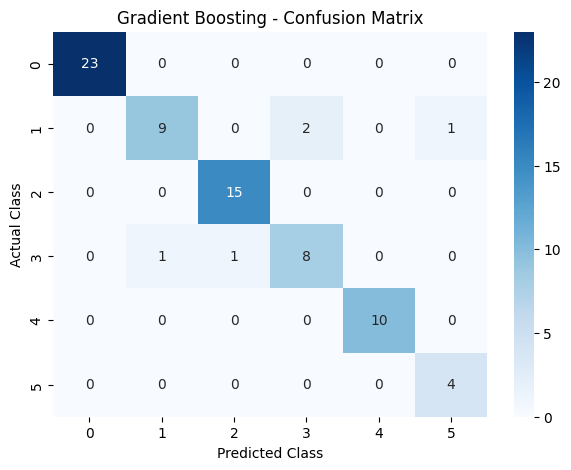

In [124]:
cm_gb = confusion_matrix(y_test, gb_pred)

print(cm_gb)

plt.figure(figsize=(7, 5))

sns.heatmap(cm_gb,annot=True,fmt='d',cmap='Blues')

plt.title('Gradient Boosting - Confusion Matrix')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')

plt.show()

# XGBoost Model 

In [125]:
from xgboost import XGBClassifier

In [126]:
xgb_model = XGBClassifier(n_estimators=200,random_state=42,eval_metric='mlogloss')

In [127]:
y_train_xgb = y_train - 1
y_test_xgb = y_test - 1

In [128]:
xgb_model.fit(X_train,y_train_xgb)

xgb_pred = xgb_model.predict(X_test)

# Convert predictions back to original class labels
xgb_pred = xgb_pred + 1

In [129]:
print("Accuracy :", accuracy_score(y_test, xgb_pred))

print(classification_report(y_test,xgb_pred,zero_division=0))

Accuracy : 0.9324324324324325
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        23
           2       0.90      0.75      0.82        12
           3       1.00      0.93      0.97        15
           4       0.75      0.90      0.82        10
           5       0.91      1.00      0.95        10
           6       1.00      1.00      1.00         4

    accuracy                           0.93        74
   macro avg       0.93      0.93      0.93        74
weighted avg       0.94      0.93      0.93        74



In [130]:
xgb_macro_f1 = f1_score(y_test,xgb_pred,average='macro',zero_division=0)

xgb_weighted_f1 = f1_score(y_test,xgb_pred,average='weighted',zero_division=0)

print("Macro F1   :", round(xgb_macro_f1, 4))
print("Weighted F1:", round(xgb_weighted_f1, 4))

Macro F1   : 0.9257
Weighted F1: 0.9325


[[23  0  0  0  0  0]
 [ 0  9  0  3  0  0]
 [ 0  0 14  0  1  0]
 [ 0  1  0  9  0  0]
 [ 0  0  0  0 10  0]
 [ 0  0  0  0  0  4]]


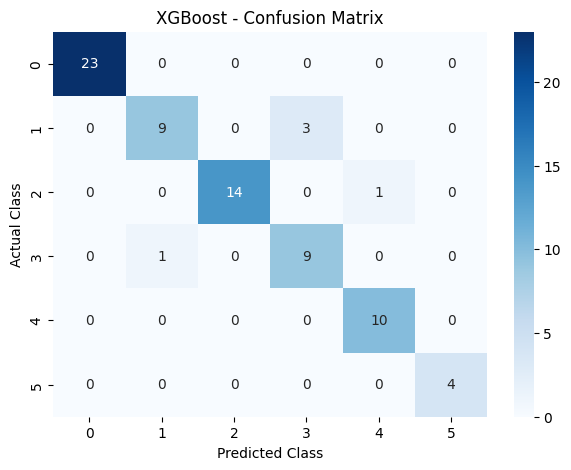

In [131]:
cm_xgb = confusion_matrix(y_test, xgb_pred)

print(cm_xgb)

plt.figure(figsize=(7, 5))

sns.heatmap(cm_xgb,annot=True,fmt='d',cmap='Blues')

plt.title('XGBoost - Confusion Matrix')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')

plt.show()

# Cross-Validation

In [132]:
from sklearn.model_selection import StratifiedKFold, cross_validate

svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', SVC(kernel='rbf',C=1.0,gamma='scale'))
])

In [133]:
skf = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)

In [134]:
svm_cv = cross_validate(svm_pipeline,X,y,cv=skf,
    scoring=[
        'accuracy',
        'precision_weighted',
        'recall_weighted',
        'f1_weighted',
        'f1_macro'
    ],n_jobs=-1)

In [135]:
svm_cv_results = pd.DataFrame({
    'Fold': range(1, 6),
    'Accuracy': svm_cv['test_accuracy'],
    'Precision': svm_cv['test_precision_weighted'],
    'Recall': svm_cv['test_recall_weighted'],
    'F1_Weighted': svm_cv['test_f1_weighted'],
    'F1_Macro': svm_cv['test_f1_macro']
})

svm_cv_results

,Fold,Accuracy,Precision,Recall,F1_Weighted,F1_Macro
0,1,0.986486,0.987452,0.986486,0.986381,0.985055
1,2,0.945205,0.947271,0.945205,0.945286,0.942226
2,3,0.986301,0.987547,0.986301,0.986330,0.984817
3,4,0.958904,0.960149,0.958904,0.958989,0.954451
4,5,0.986301,0.987547,0.986301,0.986330,0.984817


In [136]:
print("SVM Cross-Validation Results")
print("-" * 40)

print(
    "Mean Accuracy :",
    round(svm_cv['test_accuracy'].mean(), 4)
)

print(
    "Std Accuracy  :",
    round(svm_cv['test_accuracy'].std(), 4)
)

print(
    "Mean Macro F1 :",
    round(svm_cv['test_f1_macro'].mean(), 4)
)

print(
    "Std Macro F1  :",
    round(svm_cv['test_f1_macro'].std(), 4)
)

print(
    "Mean Weighted F1 :",
    round(svm_cv['test_f1_weighted'].mean(), 4)
)

print(
    "Std Weighted F1  :",
    round(svm_cv['test_f1_weighted'].std(), 4)
)

SVM Cross-Validation Results
----------------------------------------
Mean Accuracy : 0.9726
Std Accuracy  : 0.0174
Mean Macro F1 : 0.9703
Std Macro F1  : 0.0183
Mean Weighted F1 : 0.9727
Std Weighted F1  : 0.0173


# SVM Hyperparameter Tuning

In [137]:
from sklearn.model_selection import GridSearchCV

In [138]:
svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', SVC())
])

In [139]:
param_grid = {
    'model__kernel': ['linear', 'rbf', 'poly'],
    'model__C': [0.1, 1, 10, 100],
    'model__gamma': ['scale', 'auto', 0.01, 0.1, 1]
}

In [140]:
grid_search = GridSearchCV(estimator=svm_pipeline,param_grid=param_grid,scoring='f1_macro',cv=skf,n_jobs=-1,verbose=1)

In [141]:
grid_search.fit(X_train,y_train)

Fitting 5 folds for each of 60 candidates, totalling 300 fits


,estimator,"Pipeline(step...del', SVC())])"
,param_grid,"{'model__C': [0.1, 1, ...], 'model__gamma': ['scale', 'auto', ...], 'model__kernel': ['linear', 'rbf', ...]}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [142]:
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest CV Macro F1:")
print(round(grid_search.best_score_, 4))

Best Parameters:
{'model__C': 10, 'model__gamma': 'scale', 'model__kernel': 'linear'}

Best CV Macro F1:
0.9769


In [143]:
best_svm = grid_search.best_estimator_

tuned_svm_pred = best_svm.predict(X_test)

In [144]:
print("Accuracy :", accuracy_score(y_test, tuned_svm_pred))

print(classification_report(y_test,tuned_svm_pred,zero_division=0))

Accuracy : 0.972972972972973
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        23
           2       1.00      0.83      0.91        12
           3       1.00      1.00      1.00        15
           4       0.83      1.00      0.91        10
           5       1.00      1.00      1.00        10
           6       1.00      1.00      1.00         4

    accuracy                           0.97        74
   macro avg       0.97      0.97      0.97        74
weighted avg       0.98      0.97      0.97        74



In [145]:
tuned_svm_macro_f1 = f1_score(y_test,tuned_svm_pred,average='macro',zero_division=0)

tuned_svm_weighted_f1 = f1_score(y_test,tuned_svm_pred,average='weighted',zero_division=0)

print("Macro F1   :", round(tuned_svm_macro_f1, 4))
print("Weighted F1:", round(tuned_svm_weighted_f1, 4))

Macro F1   : 0.9697
Weighted F1: 0.973


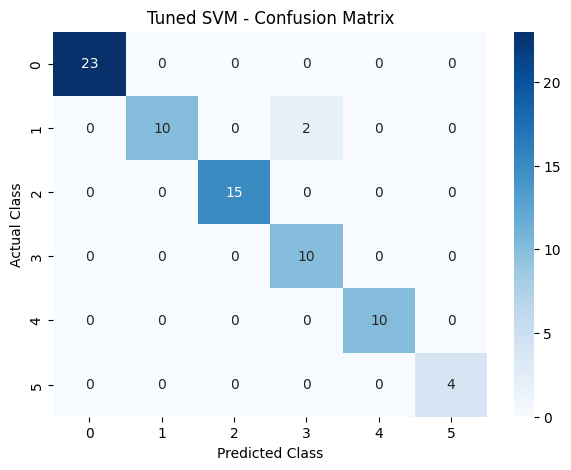

In [146]:
cm_tuned_svm = confusion_matrix(y_test,tuned_svm_pred)

plt.figure(figsize=(7, 5))

sns.heatmap(cm_tuned_svm,annot=True,fmt='d',cmap='Blues')

plt.title('Tuned SVM - Confusion Matrix')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')

plt.show()

### Hyperparameter tuning identified a linear SVM with C=10 as the best configuration based on cross-validation Macro F1 (0.9769). However, its performance on the held-out test set was identical to the baseline SVM, achieving 97.30% accuracy and 96.97% Macro F1.

In [147]:
tuned_svm_cv = cross_validate(
    best_svm,
    X_train,
    y_train,
    cv=skf,
    scoring=[
        'accuracy',
        'precision_weighted',
        'recall_weighted',
        'f1_weighted',
        'f1_macro'
    ],
    n_jobs=-1
)

In [148]:
print("Tuned SVM Cross-Validation")
print("-" * 40)

print(
    "Mean Accuracy:",
    round(tuned_svm_cv['test_accuracy'].mean(), 4)
)

print(
    "Std Accuracy:",
    round(tuned_svm_cv['test_accuracy'].std(), 4)
)

print(
    "Mean Macro F1:",
    round(tuned_svm_cv['test_f1_macro'].mean(), 4)
)

print(
    "Std Macro F1:",
    round(tuned_svm_cv['test_f1_macro'].std(), 4)
)

print(
    "Mean Weighted F1:",
    round(tuned_svm_cv['test_f1_weighted'].mean(), 4)
)

print(
    "Std Weighted F1:",
    round(tuned_svm_cv['test_f1_weighted'].std(), 4)
)

Tuned SVM Cross-Validation
----------------------------------------
Mean Accuracy: 0.9794
Std Accuracy: 0.0169
Mean Macro F1: 0.9769
Std Macro F1: 0.0186
Mean Weighted F1: 0.9793
Std Weighted F1: 0.0171


# Random Forest Tuning

In [149]:
rf_pipeline = Pipeline([('model', RandomForestClassifier(random_state=42))])

In [150]:
rf_param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [None, 10, 20, 30],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__max_features': ['sqrt', 'log2']
}

In [151]:
rf_grid = GridSearchCV(estimator=rf_pipeline,param_grid=rf_param_grid,scoring='f1_macro',cv=skf,n_jobs=-1,verbose=1)

In [152]:
rf_grid.fit(X_train,y_train)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits


,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__max_depth': [None, 10, ...], 'model__max_features': ['sqrt', 'log2'], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...], ...}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [153]:
print("Best Random Forest Parameters:")
print(rf_grid.best_params_)

print("\nBest CV Macro F1:")
print(round(rf_grid.best_score_, 4))

Best Random Forest Parameters:
{'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 10, 'model__n_estimators': 100}

Best CV Macro F1:
0.977


In [154]:
best_rf = rf_grid.best_estimator_

tuned_rf_pred = best_rf.predict(X_test)

print(classification_report(y_test,tuned_rf_pred,zero_division=0))

print("Accuracy:",round(accuracy_score(y_test, tuned_rf_pred),4))

print("Macro F1:",round(f1_score(y_test,tuned_rf_pred,average='macro',zero_division=0),4))

print("Weighted F1:",round(f1_score(y_test,tuned_rf_pred,average='weighted',zero_division=0),4))

              precision    recall  f1-score   support

           1       1.00      1.00      1.00        23
           2       0.92      0.92      0.92        12
           3       1.00      1.00      1.00        15
           4       0.90      0.90      0.90        10
           5       1.00      1.00      1.00        10
           6       1.00      1.00      1.00         4

    accuracy                           0.97        74
   macro avg       0.97      0.97      0.97        74
weighted avg       0.97      0.97      0.97        74

Accuracy: 0.973
Macro F1: 0.9694
Weighted F1: 0.973


In [155]:
tuned_rf_cv = cross_validate(
    best_rf,
    X_train,
    y_train,
    cv=skf,
    scoring=[
        'accuracy',
        'precision_weighted',
        'recall_weighted',
        'f1_weighted',
        'f1_macro'
    ],
    n_jobs=-1
)

print("Tuned Random Forest Cross-Validation")
print("-" * 45)

print(
    "Mean Accuracy:",
    round(tuned_rf_cv['test_accuracy'].mean(), 4)
)

print(
    "Std Accuracy:",
    round(tuned_rf_cv['test_accuracy'].std(), 4)
)

print(
    "Mean Macro F1:",
    round(tuned_rf_cv['test_f1_macro'].mean(), 4)
)

print(
    "Std Macro F1:",
    round(tuned_rf_cv['test_f1_macro'].std(), 4)
)

print(
    "Mean Weighted F1:",
    round(tuned_rf_cv['test_f1_weighted'].mean(), 4)
)

print(
    "Std Weighted F1:",
    round(tuned_rf_cv['test_f1_weighted'].std(), 4)
)

Tuned Random Forest Cross-Validation
---------------------------------------------
Mean Accuracy: 0.9828
Std Accuracy: 0.0154
Mean Macro F1: 0.977
Std Macro F1: 0.0223
Mean Weighted F1: 0.9823
Std Weighted F1: 0.016


In [156]:
print("Best Random Forest Parameters:")
print(rf_grid.best_params_)

print("\nBest CV Macro F1:")
print(round(rf_grid.best_score_, 4))

Best Random Forest Parameters:
{'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 10, 'model__n_estimators': 100}

Best CV Macro F1:
0.977


### Random Forest was selected as the final model based on its strong cross-validation performance, achieving 98.28% mean accuracy, 97.70% mean Macro F1-score, and 98.23% mean Weighted F1-score. On the independent test set, the model achieved 97.30% accuracy and 96.94% Macro F1-score.

# Final Random Forest Evaluation

In [157]:
final_model = best_rf

final_pred = final_model.predict(X_test)

In [158]:
final_accuracy = accuracy_score(y_test, final_pred)

final_precision = precision_score(y_test,final_pred,average='weighted',zero_division=0)

final_recall = recall_score(y_test,final_pred,average='weighted',zero_division=0)

final_f1 = f1_score(y_test,final_pred,average='weighted',zero_division=0)

final_macro_f1 = f1_score(y_test,final_pred,average='macro',zero_division=0)

print("FINAL RANDOM FOREST PERFORMANCE")
print("-" * 45)
print(f"Accuracy     : {final_accuracy:.4f}")
print(f"Precision    : {final_precision:.4f}")
print(f"Recall       : {final_recall:.4f}")
print(f"F1 Score     : {final_f1:.4f}")
print(f"Macro F1     : {final_macro_f1:.4f}")

FINAL RANDOM FOREST PERFORMANCE
---------------------------------------------
Accuracy     : 0.9730
Precision    : 0.9730
Recall       : 0.9730
F1 Score     : 0.9730
Macro F1     : 0.9694


In [159]:
print(classification_report(y_test,final_pred,zero_division=0))

              precision    recall  f1-score   support

           1       1.00      1.00      1.00        23
           2       0.92      0.92      0.92        12
           3       1.00      1.00      1.00        15
           4       0.90      0.90      0.90        10
           5       1.00      1.00      1.00        10
           6       1.00      1.00      1.00         4

    accuracy                           0.97        74
   macro avg       0.97      0.97      0.97        74
weighted avg       0.97      0.97      0.97        74



In [160]:
final_cm = confusion_matrix(y_test,final_pred)

print(final_cm)

[[23  0  0  0  0  0]
 [ 0 11  0  1  0  0]
 [ 0  0 15  0  0  0]
 [ 0  1  0  9  0  0]
 [ 0  0  0  0 10  0]
 [ 0  0  0  0  0  4]]


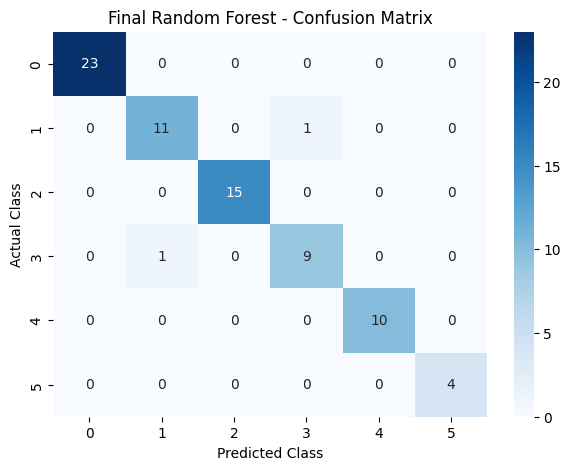

In [161]:
plt.figure(figsize=(7, 5))

sns.heatmap(final_cm,annot=True,fmt='d',cmap='Blues')

plt.title('Final Random Forest - Confusion Matrix')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')

plt.show()

In [162]:
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': final_model.named_steps['model'].feature_importances_
})

feature_importance_df = (
    feature_importance_df
    .sort_values(
        by='Importance',
        ascending=False
    )
    .reset_index(drop=True)
)

feature_importance_df.head(20)

,Feature,Importance
0,clubbing_of_the_rete_ridges,0.086585
1,fibrosis_of_the_papillary_dermis,0.084937
2,thinning_of_the_suprapapillary_epidermis,0.077702
3,spongiosis,0.064388
4,elongation_of_the_rete_ridges,0.063339
5,koebner_phenomenon,0.063104
6,vacuolisation_and_damage_of_basal_layer,0.046530
7,PNL_infiltrate,0.042884
8,focal_hypergranulosis,0.038813
9,band-like_infiltrate,0.038421


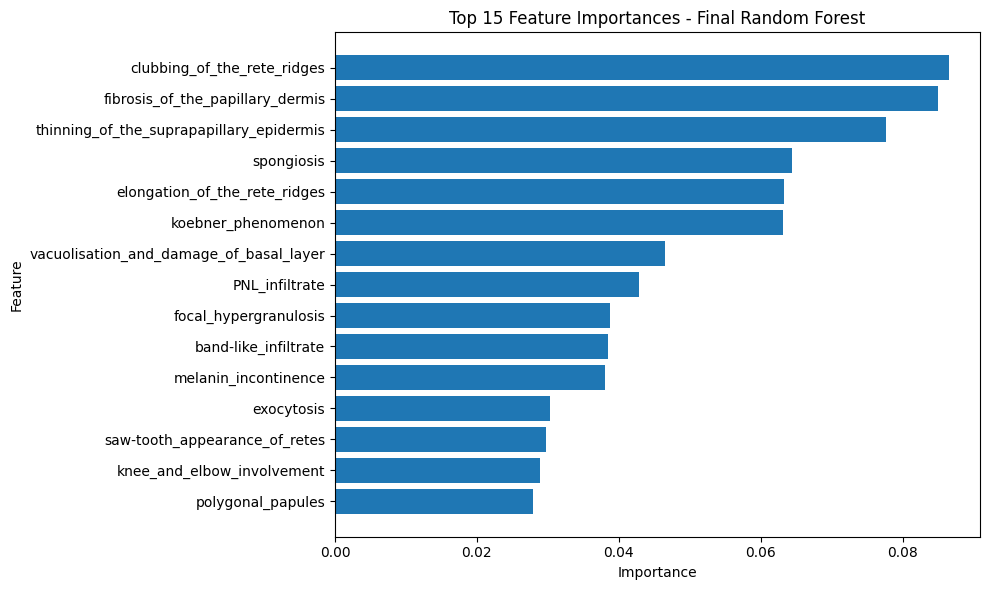

In [163]:
top_features = feature_importance_df.head(15)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features['Feature'][::-1],
    top_features['Importance'][::-1]
)

plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 15 Feature Importances - Final Random Forest')

plt.tight_layout()
plt.show()

In [164]:
from sklearn.inspection import permutation_importance

perm_result = permutation_importance(final_model,X_test,y_test,scoring='f1_macro',n_repeats=20,random_state=42,n_jobs=-1)

In [165]:
permutation_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance_Mean': perm_result.importances_mean,
    'Importance_Std': perm_result.importances_std
})

permutation_importance_df = (
    permutation_importance_df
    .sort_values(
        by='Importance_Mean',
        ascending=False
    )
    .reset_index(drop=True)
)

permutation_importance_df.head(20)

,Feature,Importance_Mean,Importance_Std
0,koebner_phenomenon,0.074335,0.026243
1,fibrosis_of_the_papillary_dermis,0.067927,0.025473
2,perifollicular_parakeratosis,0.029921,0.000000
3,clubbing_of_the_rete_ridges,0.029112,0.019759
4,disappearance_of_the_granular_layer,0.028922,0.015641
5,Age,0.026929,0.008976
6,thinning_of_the_suprapapillary_epidermis,0.025924,0.018291
7,knee_and_elbow_involvement,0.020944,0.013711
8,PNL_infiltrate,0.017312,0.017712
9,spongiosis,0.014460,0.009670


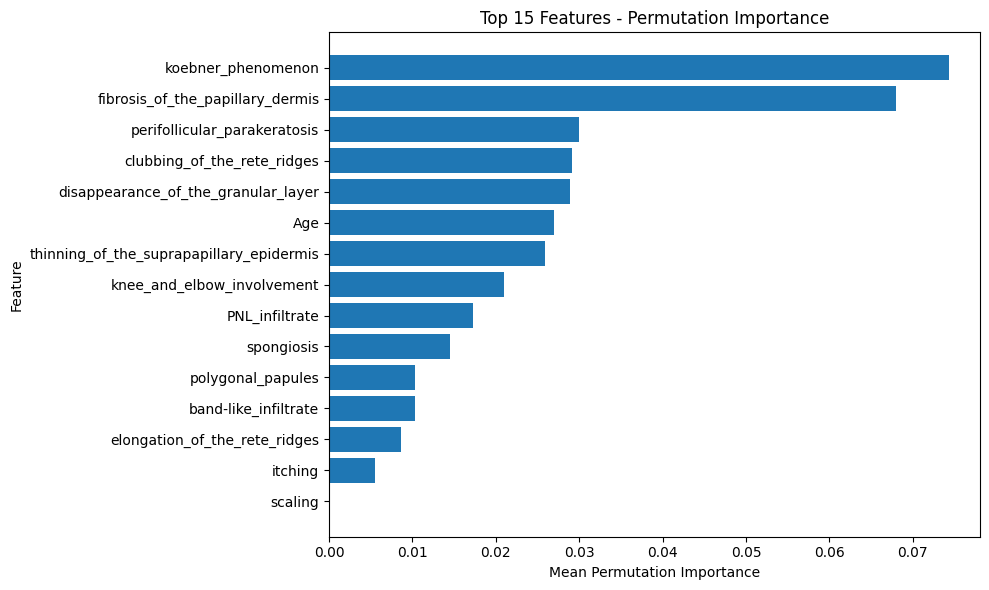

In [166]:
top_perm = permutation_importance_df.head(15)

plt.figure(figsize=(10, 6))

plt.barh(
    top_perm['Feature'][::-1],
    top_perm['Importance_Mean'][::-1]
)

plt.xlabel('Mean Permutation Importance')
plt.ylabel('Feature')
plt.title('Top 15 Features - Permutation Importance')

plt.tight_layout()
plt.show()

# Multiclass ROC-AUC

In [167]:
y_test_proba = final_model.predict_proba(X_test)

print(y_test_proba.shape)

(74, 6)


In [168]:
from sklearn.preprocessing import label_binarize

classes = sorted(y_test.unique())

y_test_bin = label_binarize(y_test,classes=classes)

print(y_test_bin.shape)

(74, 6)


In [169]:
from sklearn.metrics import roc_auc_score

roc_auc_macro = roc_auc_score(y_test_bin,y_test_proba,multi_class='ovr',average='macro')

roc_auc_weighted = roc_auc_score(y_test_bin,y_test_proba,multi_class='ovr',average='weighted')

print("Macro ROC-AUC   :", round(roc_auc_macro, 4))
print("Weighted ROC-AUC:", round(roc_auc_weighted, 4))

Macro ROC-AUC   : 0.9977
Weighted ROC-AUC: 0.9978


In [170]:
for i, cls in enumerate(classes):
    auc = roc_auc_score(
        y_test_bin[:, i],
        y_test_proba[:, i]
    )

    print(f"Class {cls} ROC-AUC: {auc:.4f}")

Class 1 ROC-AUC: 1.0000
Class 2 ROC-AUC: 0.9892
Class 3 ROC-AUC: 1.0000
Class 4 ROC-AUC: 0.9969
Class 5 ROC-AUC: 1.0000
Class 6 ROC-AUC: 1.0000


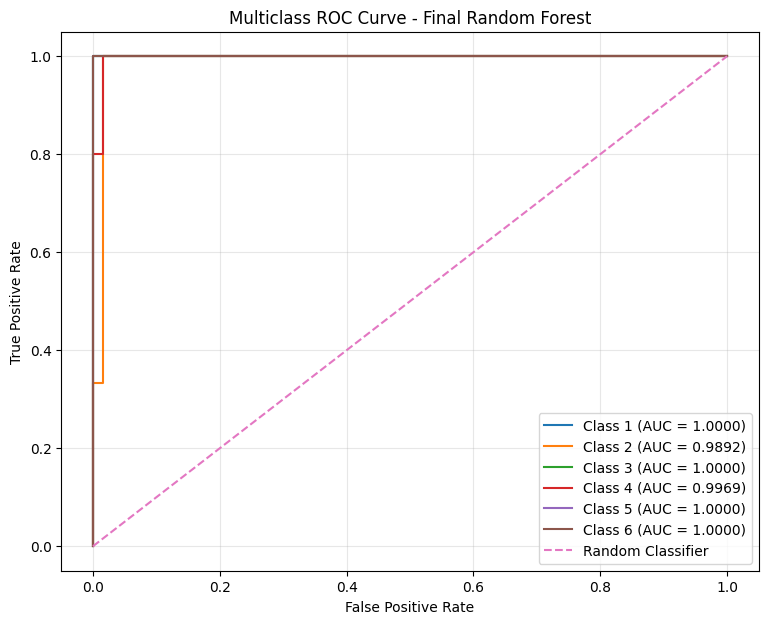

In [171]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 7))

for i, cls in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i],y_test_proba[:, i])

    roc_auc = auc(fpr, tpr)

    plt.plot(fpr,tpr,label=f'Class {cls} (AUC = {roc_auc:.4f})')

plt.plot([0, 1],[0, 1],linestyle='--',label='Random Classifier')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC Curve - Final Random Forest')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Final Prediction Pipeline

In [172]:
print(final_model)

Pipeline(steps=[('model',
                 RandomForestClassifier(min_samples_split=10,
                                        random_state=42))])


In [173]:
print("Number of features:", len(X.columns))
print("Features:", list(X.columns))

Number of features: 34
Features: ['erythema', 'scaling', 'definite_borders', 'itching', 'koebner_phenomenon', 'polygonal_papules', 'follicular_papules', 'oral_mucosal_involvement', 'knee_and_elbow_involvement', 'scalp_involvement', 'family_history', 'melanin_incontinence', 'eosinophils_in_the_infiltrate', 'PNL_infiltrate', 'fibrosis_of_the_papillary_dermis', 'exocytosis', 'acanthosis', 'hyperkeratosis', 'parakeratosis', 'clubbing_of_the_rete_ridges', 'elongation_of_the_rete_ridges', 'thinning_of_the_suprapapillary_epidermis', 'spongiform_pustule', 'munro_microabcess', 'focal_hypergranulosis', 'disappearance_of_the_granular_layer', 'vacuolisation_and_damage_of_basal_layer', 'spongiosis', 'saw-tooth_appearance_of_retes', 'follicular_horn_plug', 'perifollicular_parakeratosis', 'inflammatory_monoluclear_inflitrate', 'band-like_infiltrate', 'Age']


In [174]:
sample_patient = X_test.iloc[[0]]

print(sample_patient)

    erythema  scaling  definite_borders  itching  koebner_phenomenon  \
35         2        2                 1        2                   0   

    polygonal_papules  follicular_papules  oral_mucosal_involvement  \
35                  0                   0                         0   

    knee_and_elbow_involvement  scalp_involvement  ...  focal_hypergranulosis  \
35                           0                  0  ...                      0   

    disappearance_of_the_granular_layer  \
35                                    0   

    vacuolisation_and_damage_of_basal_layer  spongiosis  \
35                                        0           0   

    saw-tooth_appearance_of_retes  follicular_horn_plug  \
35                              0                     0   

    perifollicular_parakeratosis  inflammatory_monoluclear_inflitrate  \
35                             0                                    0   

    band-like_infiltrate   Age  
35                     0  35.0  

[1 rows x 

In [175]:
X_test.iloc[[0]]

,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,...,focal_hypergranulosis,disappearance_of_the_granular_layer,vacuolisation_and_damage_of_basal_layer,spongiosis,saw-tooth_appearance_of_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_monoluclear_inflitrate,band-like_infiltrate,Age
35,2,2,1,2,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,35.0


In [176]:
predicted_class = final_model.predict(sample_patient)

print("Predicted Class:", predicted_class[0])

Predicted Class: 2


In [177]:
probabilities = final_model.predict_proba(sample_patient)

print(probabilities)

[[0.07933333 0.44294752 0.01081624 0.2149712  0.20535986 0.04657184]]


In [178]:
probability_df = pd.DataFrame(probabilities,columns=final_model.classes_)

probability_df

,1,2,3,4,5,6
0,0.079333,0.442948,0.010816,0.214971,0.20536,0.046572


In [179]:
for cls, prob in zip(
    final_model.classes_,
    probabilities[0]
):
    print(f"Class {cls}: {prob:.2%}")

Class 1: 7.93%
Class 2: 44.29%
Class 3: 1.08%
Class 4: 21.50%
Class 5: 20.54%
Class 6: 4.66%


### Final Prediction Function

In [180]:
def predict_skin_disease(patient_data):
    
    prediction = final_model.predict(patient_data)[0]
    probabilities = final_model.predict_proba(patient_data)[0]
    
    print("=" * 45)
    print("SKIN DISEASE PREDICTION")
    print("=" * 45)
    
    print(f"Predicted Class: {prediction}")
    
    print("\nClass Probabilities:")
    
    for cls, prob in zip(
        final_model.classes_,
        probabilities
    ):
        print(f"Class {cls}: {prob:.2%}")
    
    print("=" * 45)

In [181]:
predict_skin_disease(sample_patient)

SKIN DISEASE PREDICTION
Predicted Class: 2

Class Probabilities:
Class 1: 7.93%
Class 2: 44.29%
Class 3: 1.08%
Class 4: 21.50%
Class 5: 20.54%
Class 6: 4.66%


# Save the Final Model

In [182]:
import joblib

joblib.dump(final_model,"skin_disease_random_forest_pipeline.pkl")

['skin_disease_random_forest_pipeline.pkl']

In [183]:
import os

print("Model saved:",os.path.exists("skin_disease_random_forest_pipeline.pkl"))

Model saved: True


In [184]:
loaded_model = joblib.load("skin_disease_random_forest_pipeline.pkl")

In [185]:
loaded_prediction = loaded_model.predict(sample_patient)

print("Prediction:", loaded_prediction[0])

Prediction: 2


In [187]:
print("Same prediction:",predicted_class[0] == loaded_prediction[0])

Same prediction: True


# Suggestions to Doctors for Early Identification

### 1 — Start With a Structured Clinical Assessment
Doctors should systematically record the major clinical features during the initial examination rather than relying on a single visible symptom.


### 2 — Pay Particular Attention to High-Value Features
When histopathological examination is performed, doctors should carefully evaluate multiple relevant microscopic characteristics rather than focusing on only one histopathological finding.

### 3 — Consider Patient Age
Patient age should be considered as one contextual variable during assessment, particularly when combined with the patient's clinical and histopathological characteristics.

### 4 — Consider Family History
Doctors should routinely document relevant family history during the initial patient assessment because it can provide additional contextual information when combined with other clinical findings.

### 5 — Use Histopathology When Clinical Features Overlap
When the clinical presentation does not clearly distinguish between diseases, histopathological examination should be considered as part of the diagnostic workflow according to clinical judgment.

### 6 — Use ML as Decision Support, Not as a Replacement for Doctors
The machine-learning model can be used as a decision-support tool to help prioritize possible disease classes and identify cases that may require further clinical or histopathological evaluation. Final diagnosis should remain with a qualified healthcare professional.

### 7 — Investigate Uncertain Predictions
Cases where the model produces a relatively uncertain prediction should receive additional clinical review rather than being treated as definitive classifications.

### 8 — Pay Attention to Class 2 and Class 4
When clinical or model-based evidence suggests Classes 2 and 4, additional attention should be given to differentiating characteristics and, when clinically appropriate, further examination should be considered.

### Suggestions to Doctors for Early Identification
The analysis indicates that early identification of erythemato-squamous skin diseases should consider multiple clinical and histopathological characteristics because the diseases may share similar features. Doctors should perform a structured clinical assessment including erythema, scaling, itching, Koebner phenomenon, papules, mucosal involvement, knee and elbow involvement, scalp involvement, family history and patient age. When clinical characteristics overlap, histopathological examination can provide additional information. The machine-learning model developed in this project can be considered as a decision-support tool for identifying possible disease classes and prioritizing cases for further evaluation. Predictions with relatively low confidence should be reviewed carefully rather than treated as definitive diagnoses. The final diagnosis should always be based on qualified clinical assessment and appropriate medical examination.  

# Model Comparison Report

Multiple machine-learning models were evaluated for the classification of six skin-disease classes. The models were compared using accuracy, precision, recall, F1-score, cross-validation performance and ROC-AUC.

The final evaluation showed that the tuned SVM and tuned Random Forest achieved similar test-set performance, with an accuracy of approximately 97.30%.

The tuned Random Forest achieved a mean cross-validation accuracy of 98.28%, mean Macro F1 of 97.70% and mean Weighted F1 of 98.23%. Its test-set accuracy was 97.30%, with a Macro F1 of 96.94% and Weighted F1 of 97.30%.

The final Random Forest also achieved a Macro ROC-AUC of 99.77% and Weighted ROC-AUC of 99.78%.

Based on the overall evaluation, the tuned Random Forest was selected as the preferred model for this project. It provides strong predictive performance and also offers feature-importance information, which helps in understanding which clinical and histopathological features contribute to the model's predictions.

However, this model should be considered a prototype decision-support system rather than a clinically validated diagnostic system. The dataset contains only 366 records, so further validation using larger and independent clinical datasets would be required before real-world clinical deployment.

# Report on Challenges faced

| Challenge                       | Technique Used                                 | Reason                                                                   |
| ------------------------------- | ---------------------------------------------- | ------------------------------------------------------------------------ |
| Missing Age values (`?`)        | Median imputation                              | Preserve observations and handle missing numerical values                |
| Age = 0                         | Retained after investigation                   | No evidence in project documentation that 0 is invalid                   |
| Class imbalance                 | Stratified splitting + Macro F1                | Preserve class proportions and evaluate all classes fairly               |
| Small dataset                   | 5-fold stratified CV                           | Obtain a more stable estimate of model performance                       |
| Highly correlated features      | Correlation analysis                           | Identify redundancy without unnecessarily removing useful information    |
| Different feature rankings      | Feature importance + permutation importance    | Obtain broader model interpretation                                      |
| Model selection                 | Multiple evaluation metrics                    | Avoid choosing a model based only on accuracy                            |
| Similar disease characteristics | Combined clinical + histopathological features | Capture multiple patterns for classification                             |
| Healthcare application          | Decision-support framing                       | Avoid treating the prototype as a clinically validated diagnostic system |


During the project, several challenges were identified in the dataset and modeling process.

1. **Missing Age Values:** The Age column contained 8 missing values represented by `?`. The values were converted to numerical missing values and handled using median imputation to preserve all observations.

2. **Age Value of 0:** One observation had an Age value of 0. Since the project documentation did not explicitly identify zero as an invalid value, the observation was retained rather than removed without sufficient evidence.

3. **Class Imbalance:** The target classes were not equally distributed. Class 1 represented 30.60% of observations, while Class 6 represented only 5.46%. Stratified splitting was used to preserve class proportions, and Macro F1 was considered along with accuracy to evaluate performance across all classes.

4. **Small Dataset:** The dataset contained only 366 observations. Five-fold stratified cross-validation was therefore used to evaluate model stability across multiple data partitions.

5. **Highly Correlated Features:** Several histopathological features showed strong correlations, with some correlations exceeding 0.90. These relationships were analyzed during EDA, but features were not automatically removed because they could still contain useful predictive information for the Random Forest model.

6. **Feature Importance Differences:** Different feature-importance methods produced slightly different rankings. Both Random Forest feature importance and permutation importance were analyzed to obtain a broader understanding of feature contributions.

7. **Model Selection:** Multiple evaluation metrics including Accuracy, Precision, Recall, F1 Score, Macro F1, Weighted F1, Cross-validation and ROC-AUC were considered. The tuned Random Forest was selected based on its strong and consistent performance.

8. **Similar Disease Characteristics:** The six diseases share several clinical and histopathological characteristics. Therefore, clinical and histopathological features were analyzed together rather than relying on a single characteristic.

9. **Healthcare Application:** Despite the strong model performance, the dataset is relatively small and the model has not been clinically validated on an independent real-world population. Therefore, the final model is considered a prototype decision-support system and would require further validation before clinical deployment.

# Final Conclusion

This project developed a machine-learning-based classification system for identifying six erythemato-squamous skin disease classes using clinical and histopathological features.

The dataset contained 366 observations and 34 input features. Data preprocessing included handling missing Age values, converting Age into numerical format, checking duplicates and invalid values, analyzing class distribution, and using stratified train-test splitting.

Exploratory data analysis identified important differences between disease classes and strong correlations among several histopathological features. The analysis also showed that the target classes were moderately imbalanced, making stratified evaluation and Macro F1 important.

Several machine-learning models were evaluated. The tuned Random Forest achieved the best overall performance and was selected as the final model. It achieved 97.30% accuracy, 96.94% Macro F1, 97.30% Weighted F1, 98.28% mean cross-validation accuracy, 97.70% mean cross-validation Macro F1 and 99.77% Macro ROC-AUC on the available dataset.

The final confusion matrix showed only two misclassified observations in the test set, with one Class 2 observation predicted as Class 4 and one Class 4 observation predicted as Class 2.

Feature-importance analysis showed that several histopathological characteristics, including clubbing of the rete ridges, fibrosis of the papillary dermis, thinning of the suprapapillary epidermis, spongiosis, elongation of the rete ridges and Koebner phenomenon, contributed strongly to the model's predictions.

The developed model can potentially serve as a decision-support system to assist in the early identification and differentiation of skin-disease classes. However, it should not be considered a replacement for professional medical diagnosis. The dataset contains only 366 observations, so further evaluation using larger, independent and clinically representative datasets would be necessary before considering real-world clinical deployment.

Overall, the project demonstrates that machine learning can effectively learn patterns from combined clinical and histopathological features and provide strong classification performance for the six disease classes in this dataset.